# Bouquet — IMAS/OMAS example (FUSE data)

### What is this?

**Bouquet** propagates input uncertainty into Grad–Shafranov equilibria: it
perturbs the measured inputs within their error bars and re-solves each draw
with **TokaMaker** (OpenFUSION Toolkit), producing a *bouquet* of equilibria
spanning what the data allows.

This notebook reads its baseline from a **FUSE IMAS/OMAS** dataset, which already
carries the current **pre-separated** (inductive + bootstrap) plus the kinetic
profiles, fast-ion pressure, and targets — so there is **no reconstruction
step**. The data is synthetic, non-proprietary DIII-D-like, a 3-slice L→H ramp.

**Layout:** (1) look at the inputs, (2) a minimal run, (3) plot the outputs,
(4) upgrade to ψ-dependent uncertainties, (5) the full switchboard, (6) a
comprehensive run + the same plots, (7) the 3-slice time evolution. It mirrors
`bouquet_D3Dlike_geqdsk_example.ipynb` — the difference is the source line
(`from_imas` instead of `from_geqdsk`, no reconstruction). `plot_bouquet` is
shared: it auto-detects this IMAS archive and adds the perturbed
auxiliary-profile figure on top of the standard panels.

> **Prereq:** the OpenFUSION Toolkit on `PYTHONPATH`
> (`export PYTHONPATH=/path/to/OpenFUSIONToolkit/build_release/python:$PYTHONPATH`).


In [1]:
import os, json
try:
    import OpenFUSIONToolkit  # noqa: F401 -- bouquet imports it lazily, so check up front
except ModuleNotFoundError as e:
    raise SystemExit(
        "OpenFUSIONToolkit not importable. Put OFT on PYTHONPATH, e.g.\n"
        "  export PYTHONPATH=/path/to/OpenFUSIONToolkit/build_release/python:$PYTHONPATH"
    ) from e
import bouquet as bq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm, matplotlib.colors as mcolors
%matplotlib inline
%config InlineBackend.figure_format = "retina"
EC = 1.602176634e-19   # elementary charge (p = n·k·T in SI)
OMAS = 'D3Dlike_baseline_omas.json'   # FUSE IMAS/OMAS data dictionary
MESH = 'DIIID_mesh.h5'                # TokaMaker finite-element mesh
TIME = 2.3043                         # time slice [s] (final H-mode; §7 sweeps all)
print('bouquet', bq.__version__, 'ready')


bouquet 1.3.1 ready


## 1. Look at the inputs

The baseline at our chosen time slice: the **kinetic profiles**, the
**pre-separated currents** (the IDS keeps j_ohmic and j_BS apart — no
reconstruction needed), and the thermal + fast **pressure**. Reading the IDS
does no solve.


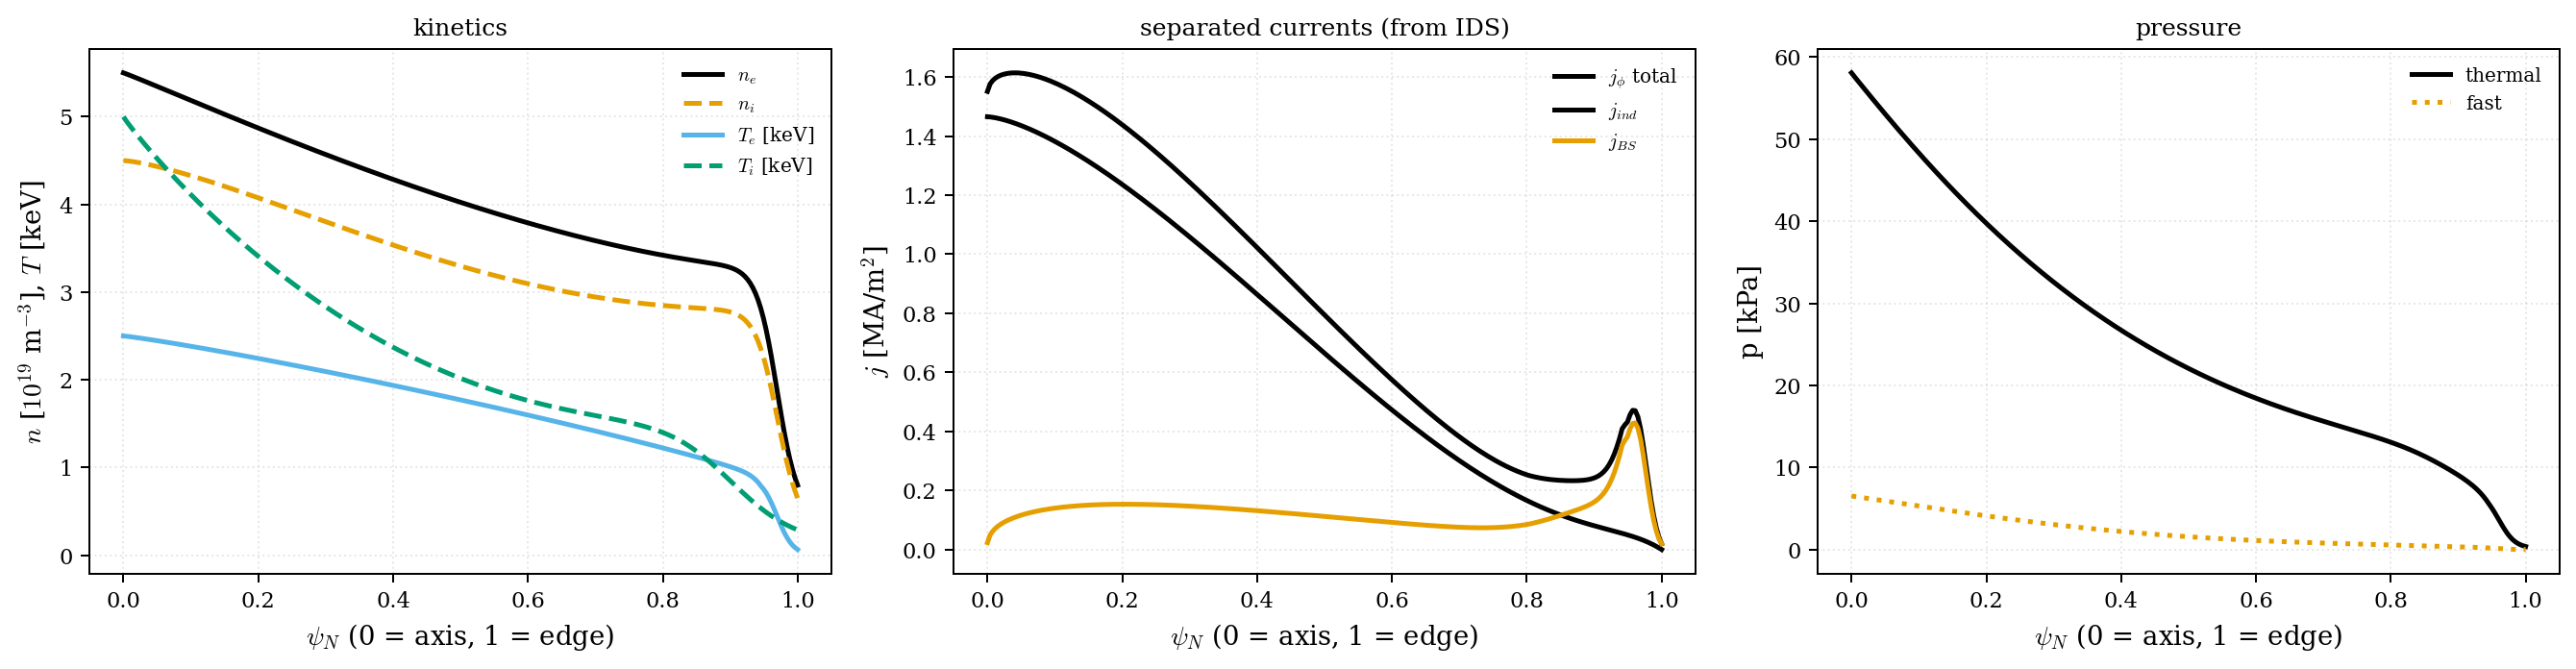

auxiliary channels available from the IDS: ['zeff', 'omega_tor', 'e_r', 'chi_e', 'chi_i']


In [2]:
# read_imas_baseline flags: kinetic_source={fuse|ida_hybrid}  anchor_jtor_to_equilibrium={T|F}  anchor_pressure_to_equilibrium={F|T}  p_fast_reduction='trace'
bl0 = bq.read_imas_baseline(bq.ImasSource(ids_path=OMAS, time=TIME))
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(bl0.psi_N, bl0.ne/1e19, label=r'$n_e$'); ax[0].plot(bl0.psi_N, bl0.ni/1e19, '--', label=r'$n_i$')
ax[0].plot(bl0.psi_N, bl0.te/1e3, label=r'$T_e$ [keV]'); ax[0].plot(bl0.psi_N, bl0.ti/1e3, '--', label=r'$T_i$ [keV]')
ax[0].set_ylabel(r'$n$ [$10^{19}$ m$^{-3}$], $T$ [keV]'); ax[0].legend(fontsize=8); ax[0].set_title('kinetics')
ax[1].plot(bl0.psi_N, bl0.j_phi/1e6, 'k', label=r'$j_\phi$ total')
ax[1].plot(bl0.psi_N, bl0.j_inductive/1e6, label=r'$j_{ind}$'); ax[1].plot(bl0.psi_N, bl0.j_BS/1e6, label=r'$j_{BS}$')
ax[1].set_ylabel(r'$j$ [MA/m$^2$]'); ax[1].legend(fontsize=8); ax[1].set_title('separated currents (from IDS)')
ax[2].plot(bl0.psi_N, EC*(bl0.ne*bl0.te + bl0.ni*bl0.ti)/1e3, label='thermal')
ax[2].plot(bl0.psi_N, bl0.p_fast/1e3, ':', label='fast'); ax[2].set_ylabel('p [kPa]'); ax[2].legend(fontsize=8); ax[2].set_title('pressure')
for a in ax: a.set_xlabel(r'$\psi_N$ (0 = axis, 1 = edge)'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('auxiliary channels available from the IDS:', list(bl0.aux or {}))


## 2. A minimal run

Create the driver, set the **uncertainty envelope** (how far each draw may
wander) and the **GPR correlation lengths** (how smooth each perturbation is in
ψ), then run. `from_imas` needs no reconstruction; `setup_solver` +
`prepare_baseline` stand up TokaMaker and forward-solve the baseline once for a
consistent `l_i`.

The kinetic σ are per-channel fractions — ne/Te at 5 %, Ti at 10 %, `j_phi` at
5 %. **Densities follow a Z_eff-consistent scheme by default:** each draw
perturbs n_e, T_e, T_i and **Z_eff** (the `zeff_scalar_sigma`, default ±5 %),
and the main-ion density n_i is *derived* from (n_e, Z_eff) by single-impurity
quasineutrality — so n_i, n_z and Z_eff stay mutually consistent and
`ni_scalar_sigma` is unused. On the IMAS path the effective impurity charge
Z_imp is taken straight from the IDS species mix (no `impurity_Z` knob needed).
Pass `zeff_scalar_sigma=0` to instead draw n_i independently and hold Z_eff at
baseline.


In [3]:
# from_imas flags: time  n_draws  header  impurity_Z=6.0  ida_path=<IDA .cdf>  LCFS_geqdsk=<g-file, optional>  kinetic_source={fuse|ida_hybrid}  anchor_pressure_to_equilibrium={F|T}
HEADER = f'D3Dlike_omas_t{TIME:.4f}'   # output -> f'{HEADER}.h5'
run = bq.Bouquet.from_imas(OMAS, mesh=MESH, time=TIME, n_draws=15, header=HEADER)

# uncertainty envelope (per-channel fractional σ)
run.uncertainty.ne_scalar_sigma = 0.05;  run.uncertainty.te_scalar_sigma = 0.05
run.uncertainty.ti_scalar_sigma = 0.10
run.uncertainty.jphi_scalar_sigma = 0.05
run.uncertainty.zeff_scalar_sigma = 0.05   # ENABLES the Z_eff channel -> n_i derived per draw
                                           # (set 0.0 for independent n_i; ni_scalar_sigma then used)
# GPR correlation lengths (ψ_N units): density / temperature / current
run.uncertainty.n_ls, run.uncertainty.t_ls, run.uncertainty.j_ls = 0.5, 0.4, 0.25
# Bootstrap-model uncertainty: scale each draw's FULL j_BS by U(0.95, 1.05) (±5%),
# a coarse stand-in for the Sauter/Redl model's inherent uncertainty (centered on
# the calibrated bs_scale). Wider (e.g. ±10%) stresses yield + the core offset.
run.generation.jBS_scale_range = (0.95, 1.05)
run.generation.seed = 42          # reproducible GPR draws
run.generation.scan_key = 2000    # label this (final-step) bouquet 2000 ms in the .h5

`prepare_baseline()` reads the IDS and **forward-solves** the baseline on the
mesh (no reconstruction — the currents are already separated), printing the
TokaMaker-vs-IDS `l_i` so you can confirm the baseline before spending draws.
Then `generate/filter/export` builds and screens the ensemble.


In [4]:
run.setup_solver()        # build the TokaMaker problem on the mesh
run.prepare_baseline();   # read the IDS + forward-solve the baseline (no reconstruction)


#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  fix/bootstrap-pchip-derivatives
Revision id:         19e08b2

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    1

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    3
  Minlev =   -1


 Inverting real matrix
   Time =    1.6379999999999999E-003


[imas SWB-split:diff] FUSE total preserved; diff min/max=-3.58e+04/6.57e+02; SWB/FUSE jBS peak=1.069


[imas forward-solve] converged (11 its, Ip -0.00%) recalc_jBS=True TokaMaker li_1=1.0926 li_3=0.8396 | IDS li_1=1.092433621055792 li_3=0.8389896962021185


### Input vs forward-solve

`plot_input_vs_recon(run)` overlays the **raw IDS input** (dotted) against the
**TokaMaker forward-solved baseline** (solid): pressure, j_phi, q, and the
separatrix (colour-coded by boundary deviation, green→red). On the IMAS path the
pressure and current are prescribed, so those panels confirm faithful input,
while **q and the separatrix** show the forward solve's geometric result. (This
synthetic IDS omits equilibrium q, so the q panel shows only the solved
profile.)

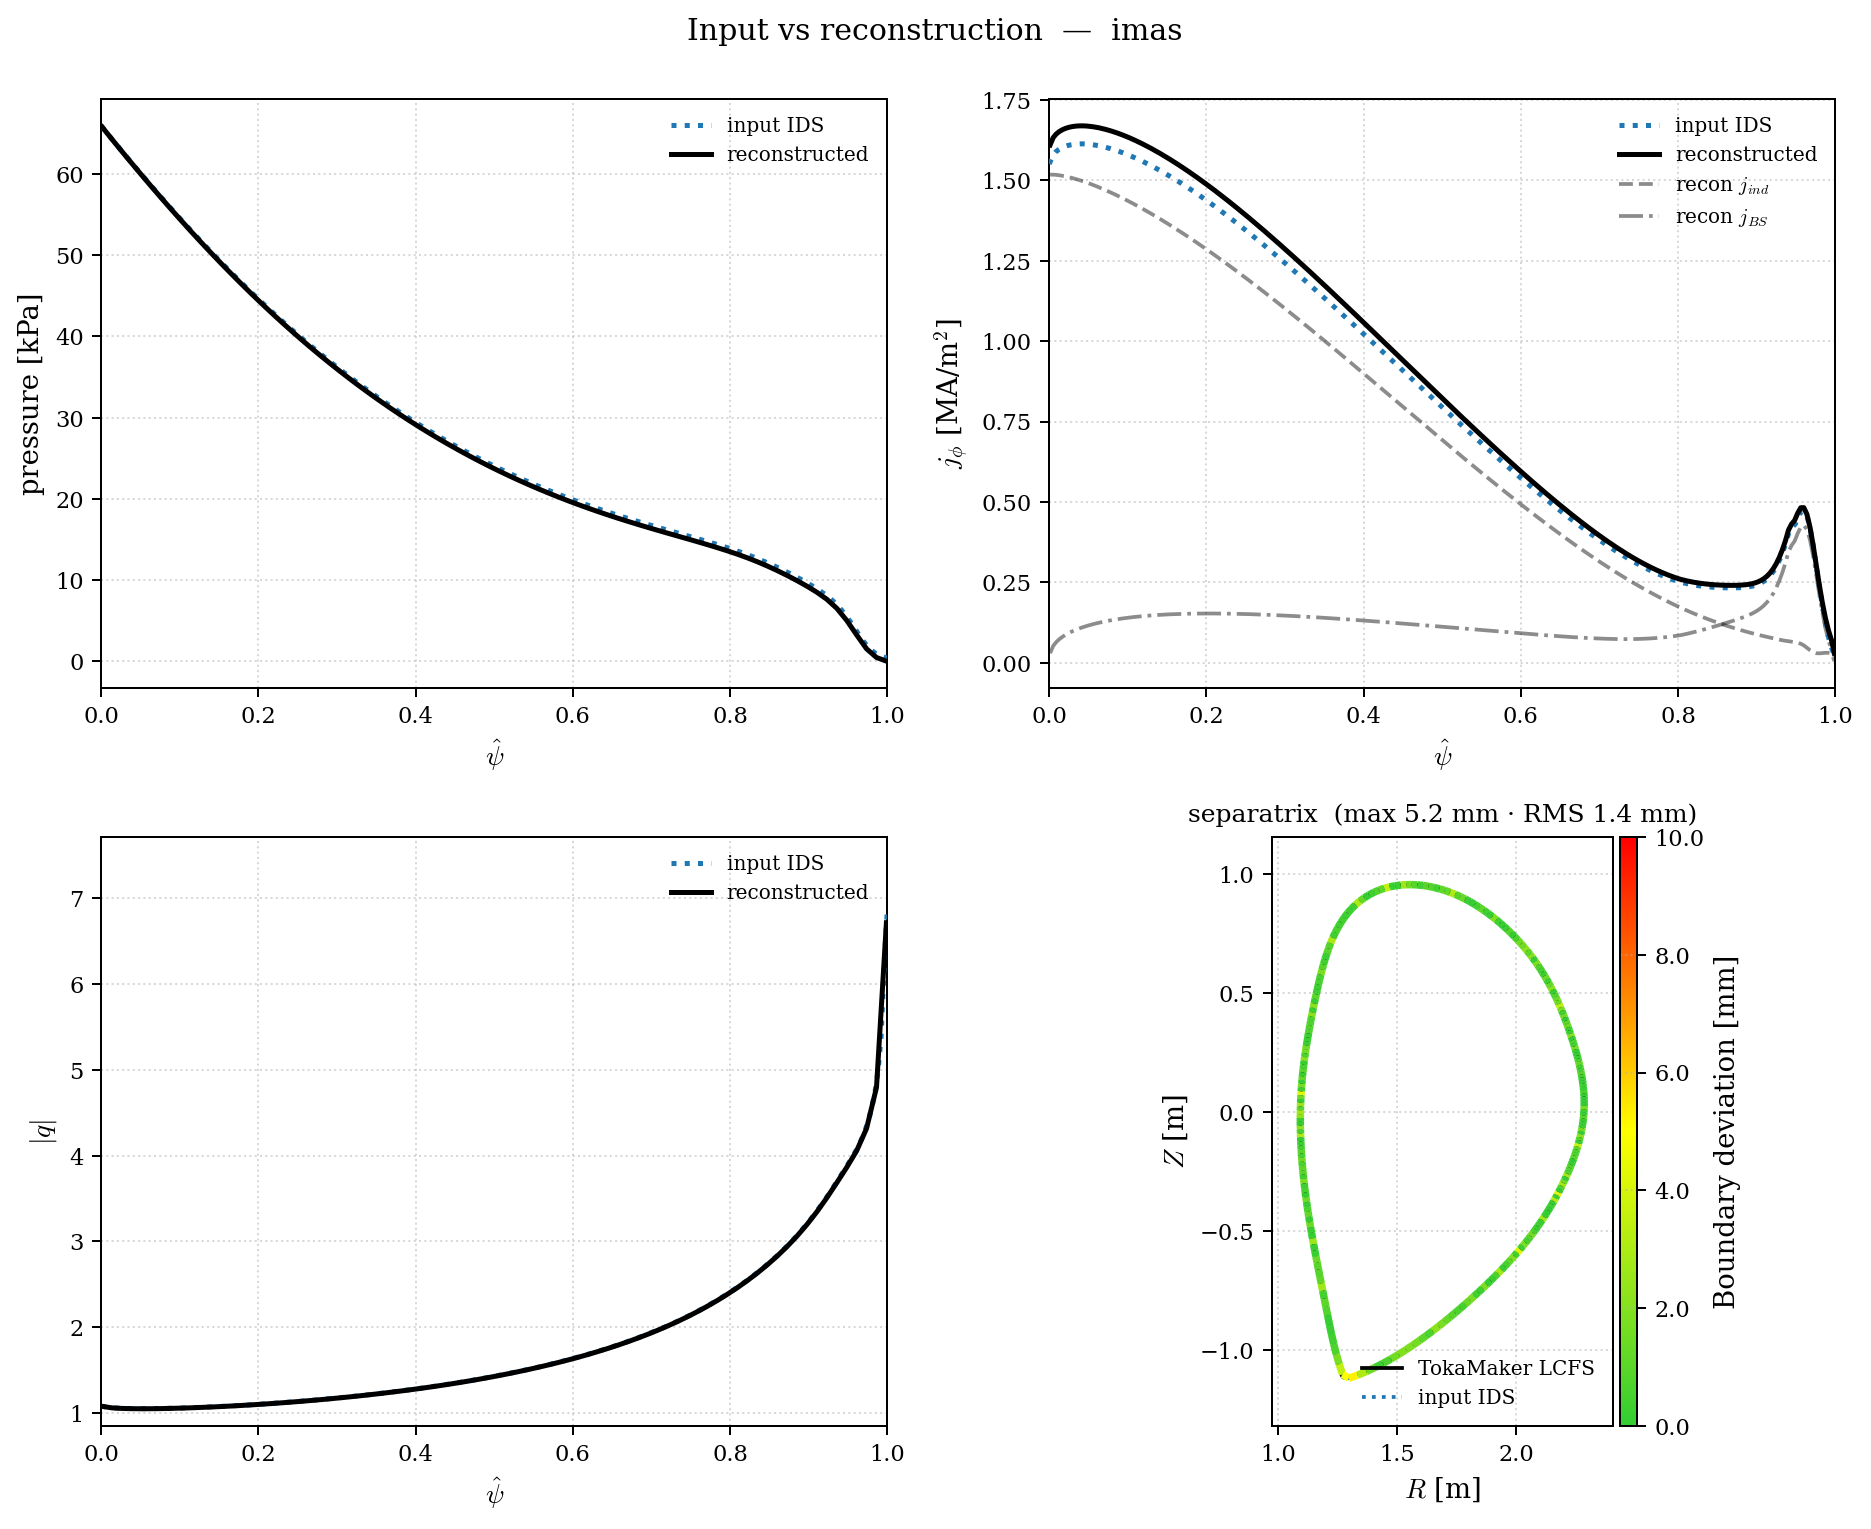

In [5]:
# plot_input_vs_recon flags: npsi=<q/pressure grid pts>  max_dev_mm=<separatrix colour scale>
bq.plot_input_vs_recon(run); plt.show()

In [6]:
run.generate(); run.filter(); run.export()    # perturb + solve + screen the draws


  [sigma-source] sigma_ne   <- scalar 0.05 x |baseline|     (peak 2.75e+18)
  [sigma-source] sigma_te   <- scalar 0.05 x |baseline|     (peak 125)
  [sigma-source] sigma_ni   <- scalar 0.1 x |baseline|      (peak 4.5e+18)
  [sigma-source] sigma_ti   <- scalar 0.1 x |baseline|      (peak 500)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 8.069e+04)



=== Bouquet — D3Dlike_omas_t2.3043 ==============  5/15 in-spec (33%)
  draws         15 generated
  coil spec     5/15 within ±2%   (10 out-of-spec)
  boundary      RMS median 2.34 mm   max 3.87 mm


'D3Dlike_omas_t2.3043_selected.h5'

## 3. Plot the bouquet outputs

Three views of the ensemble:
- **`plot_traces`** — per-draw l_i (with the acceptance band), LCFS deviation,
  and the anchor-displacement heatmap,
- **`plot_bouquet(mode='all')`** — the unified dashboard: kinetic / pressure /
  j_phi / Z_eff / q profile families plus the boundary and j_phi-decomposition
  figures. It auto-detects this IMAS archive and **also appends the perturbed
  auxiliary profiles** (rotation / transport switchboard). The same call serves
  the g-file/p-file reconstruction notebook.
- **`plot_coil_currents`** — coil-drift heatmap (a saturated cell is at/over
  spec; the VSC pair sits below the rule).

Filled markers are selected draws; open markers were excluded by the filter
(section below).


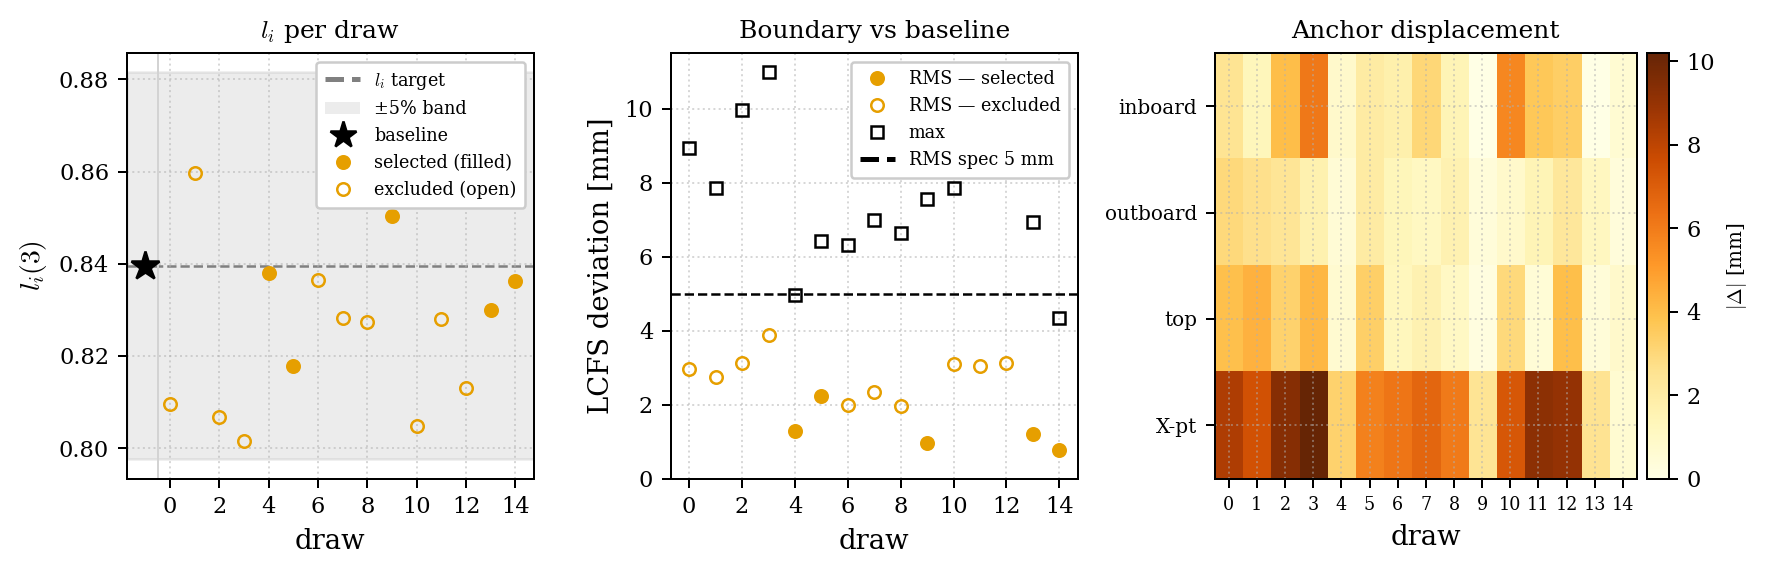

In [7]:
# plot_traces flags: scan_key={int|'all'}  li_band=<l_i accept band>  rms_max_mm=<LCFS RMS cut>
bq.plot_traces(HEADER + '.h5', scan_key=2000, li_band=run.generation.l_i_tolerance,
            rms_max_mm=run.filtering.rms_max_mm); plt.show()


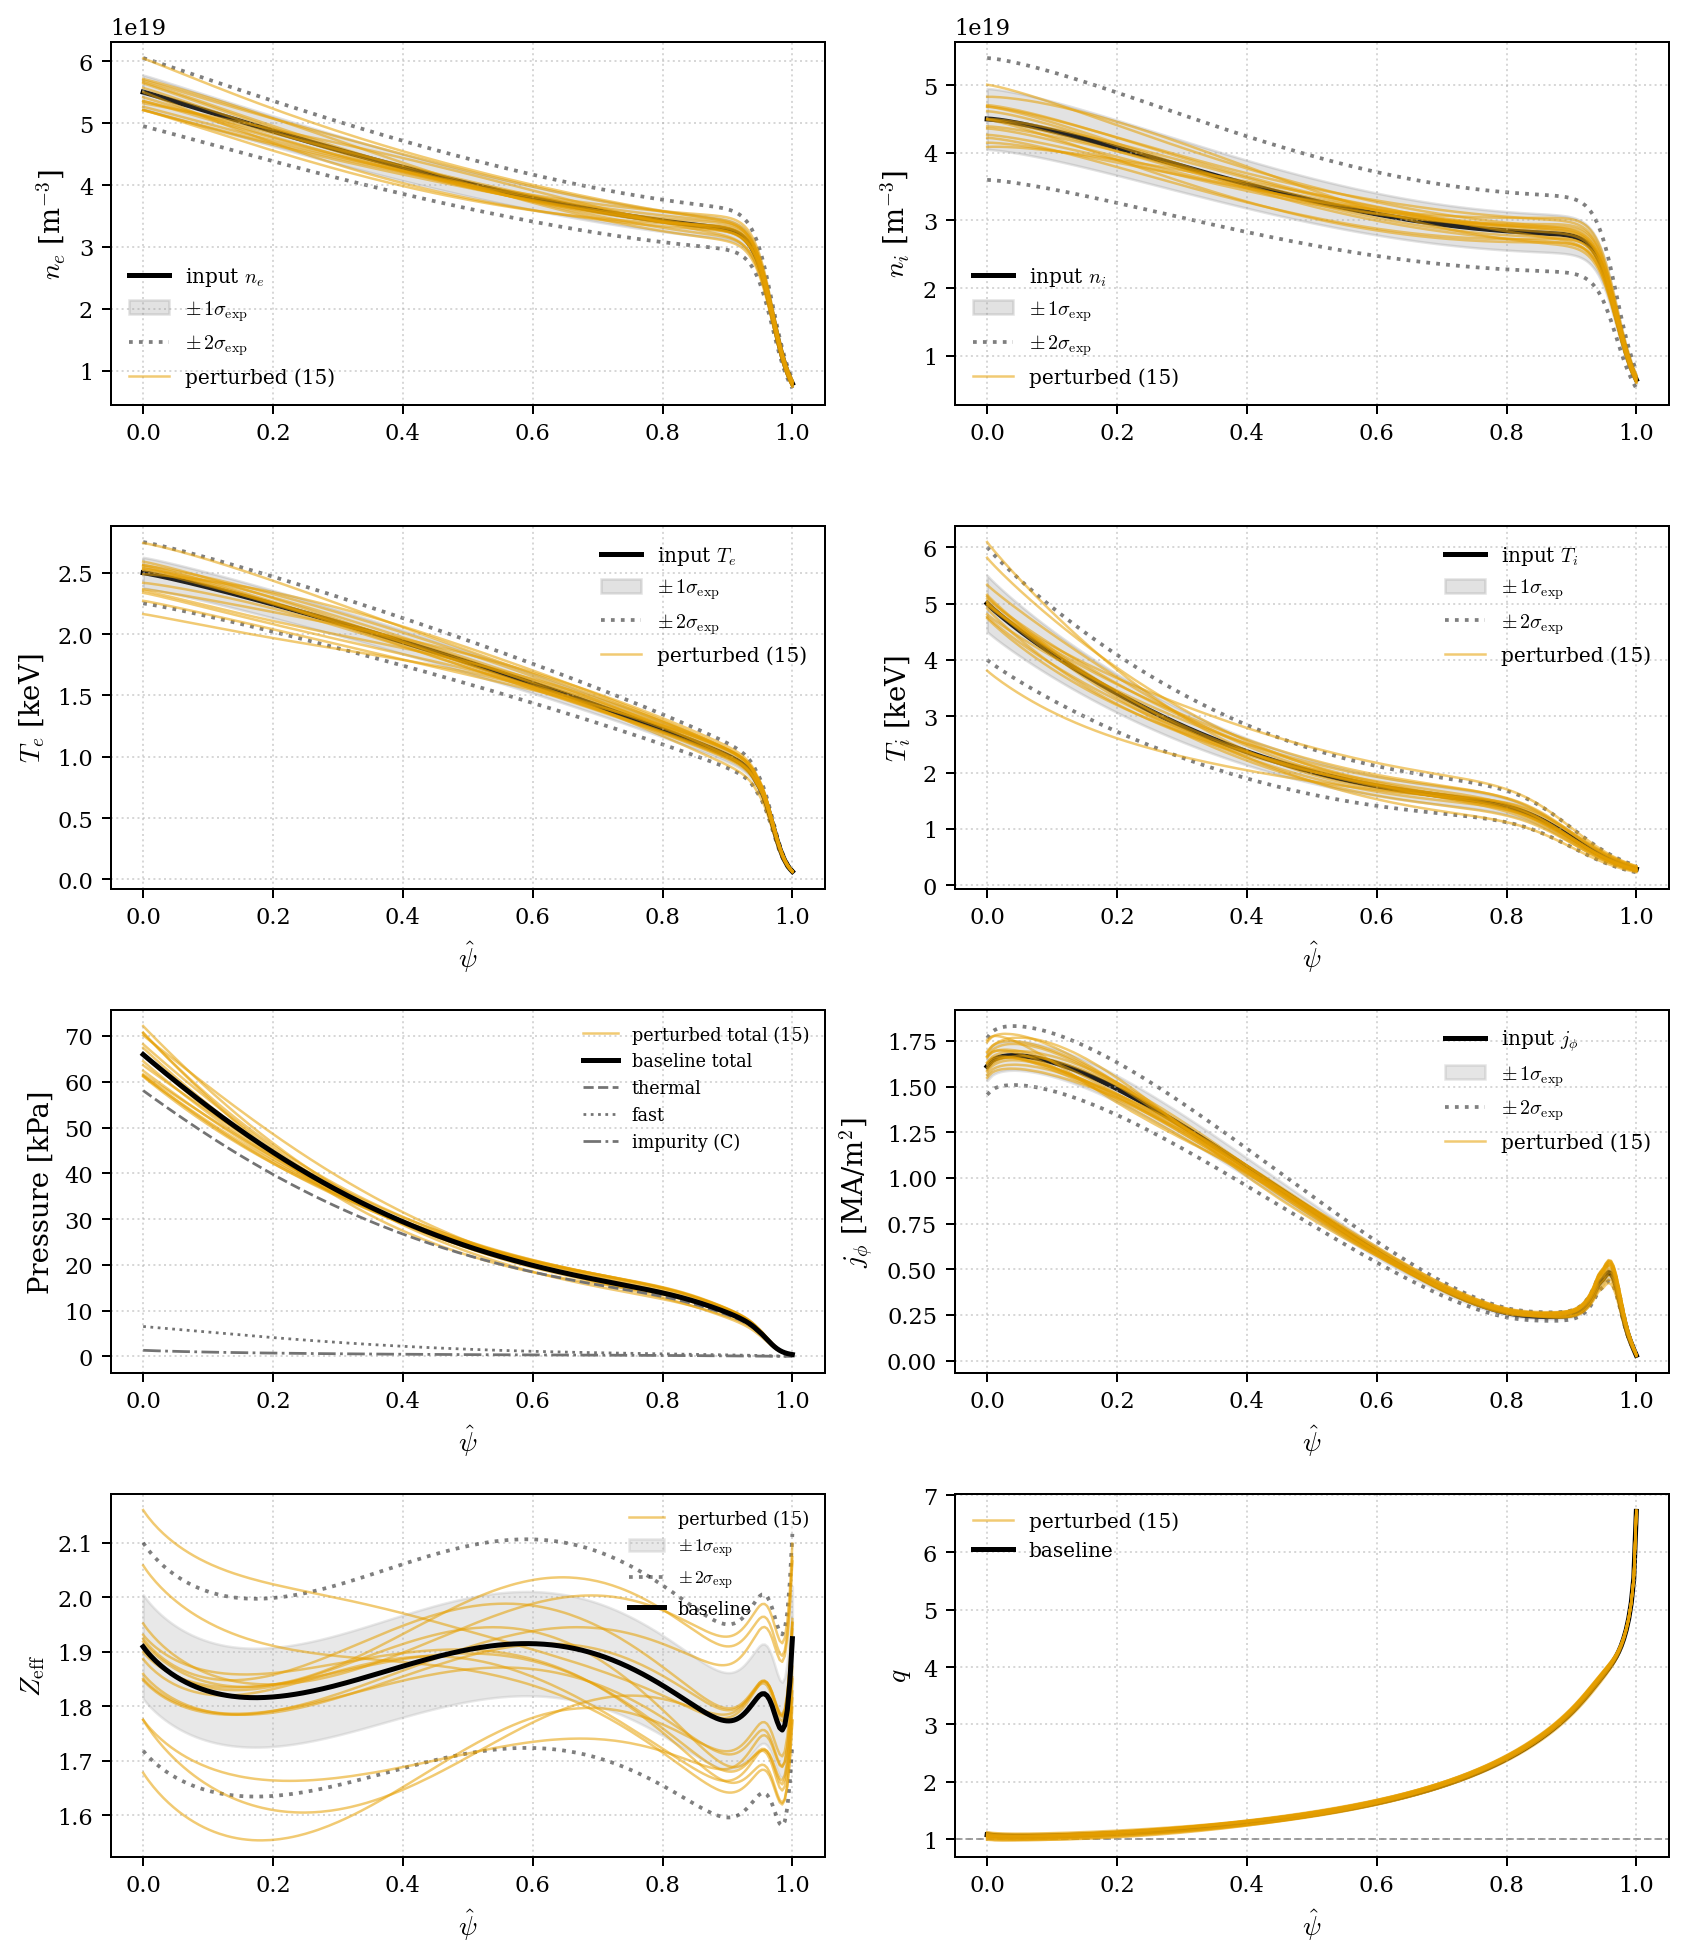

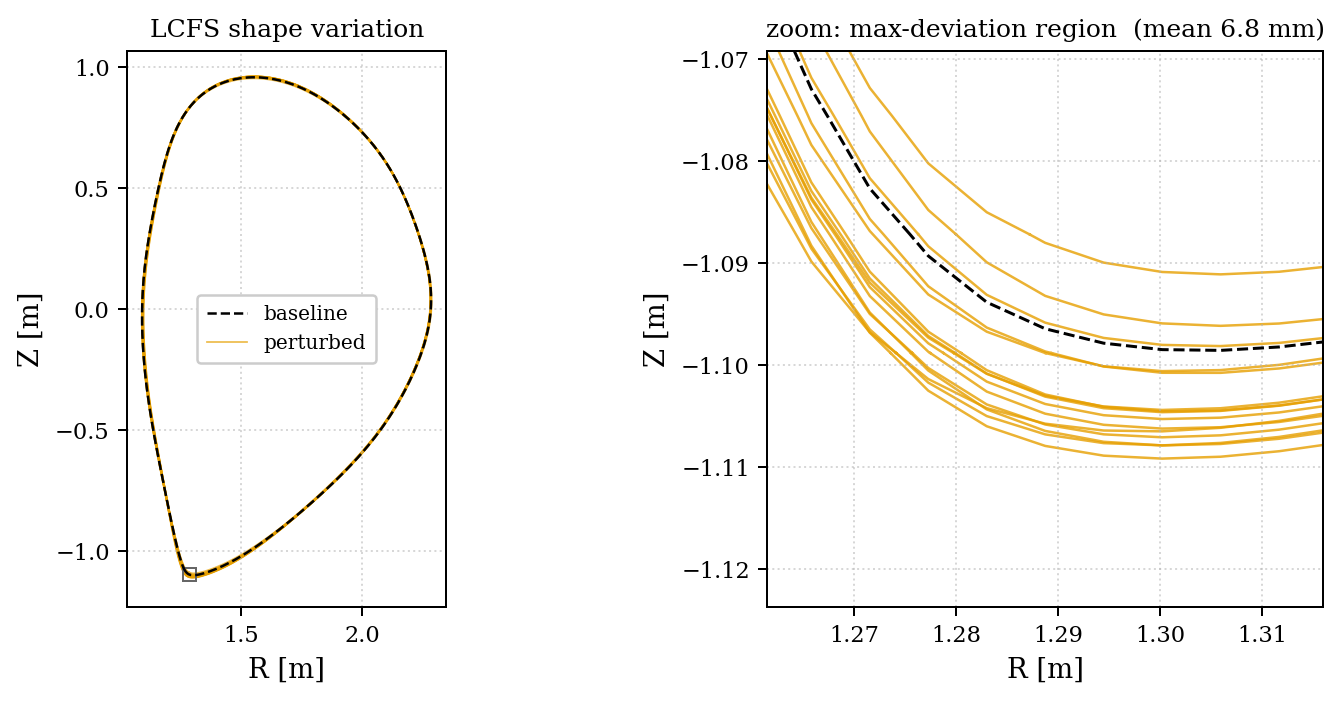

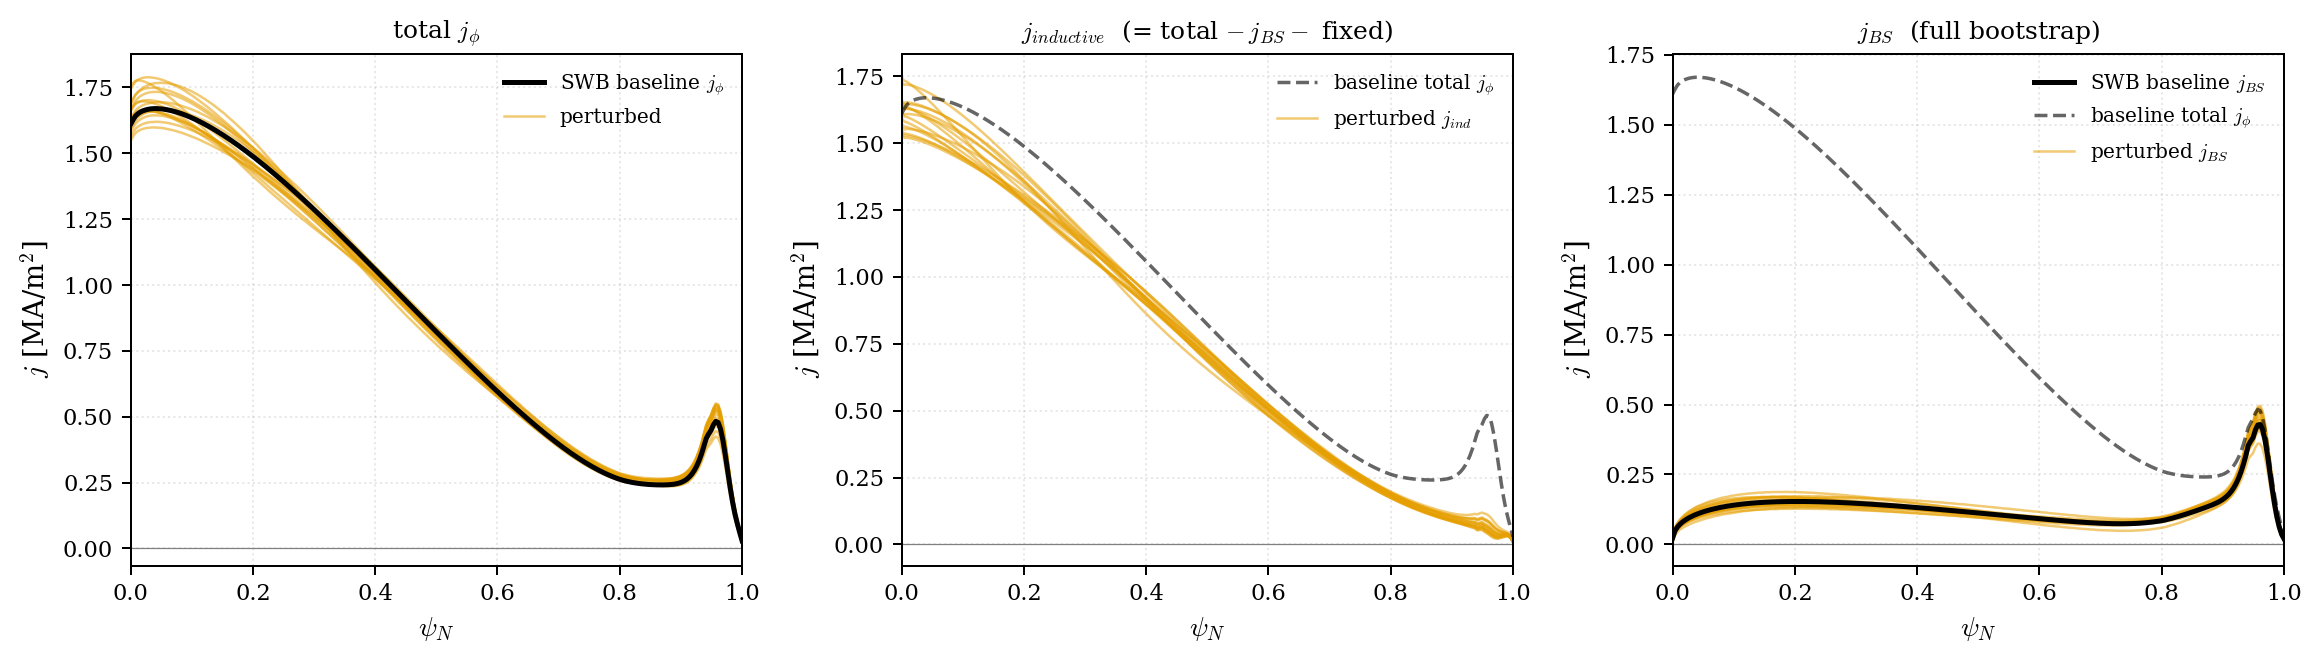

In [8]:
# plot_bouquet flags: mode={kinetic|pressure|j-phi|boundary|all}  selection={all|selected|excluded}  layout={stack|row}  pub_style={F|T}
bq.plot_bouquet(HEADER + '.h5', scan_key=2000, mode='all');


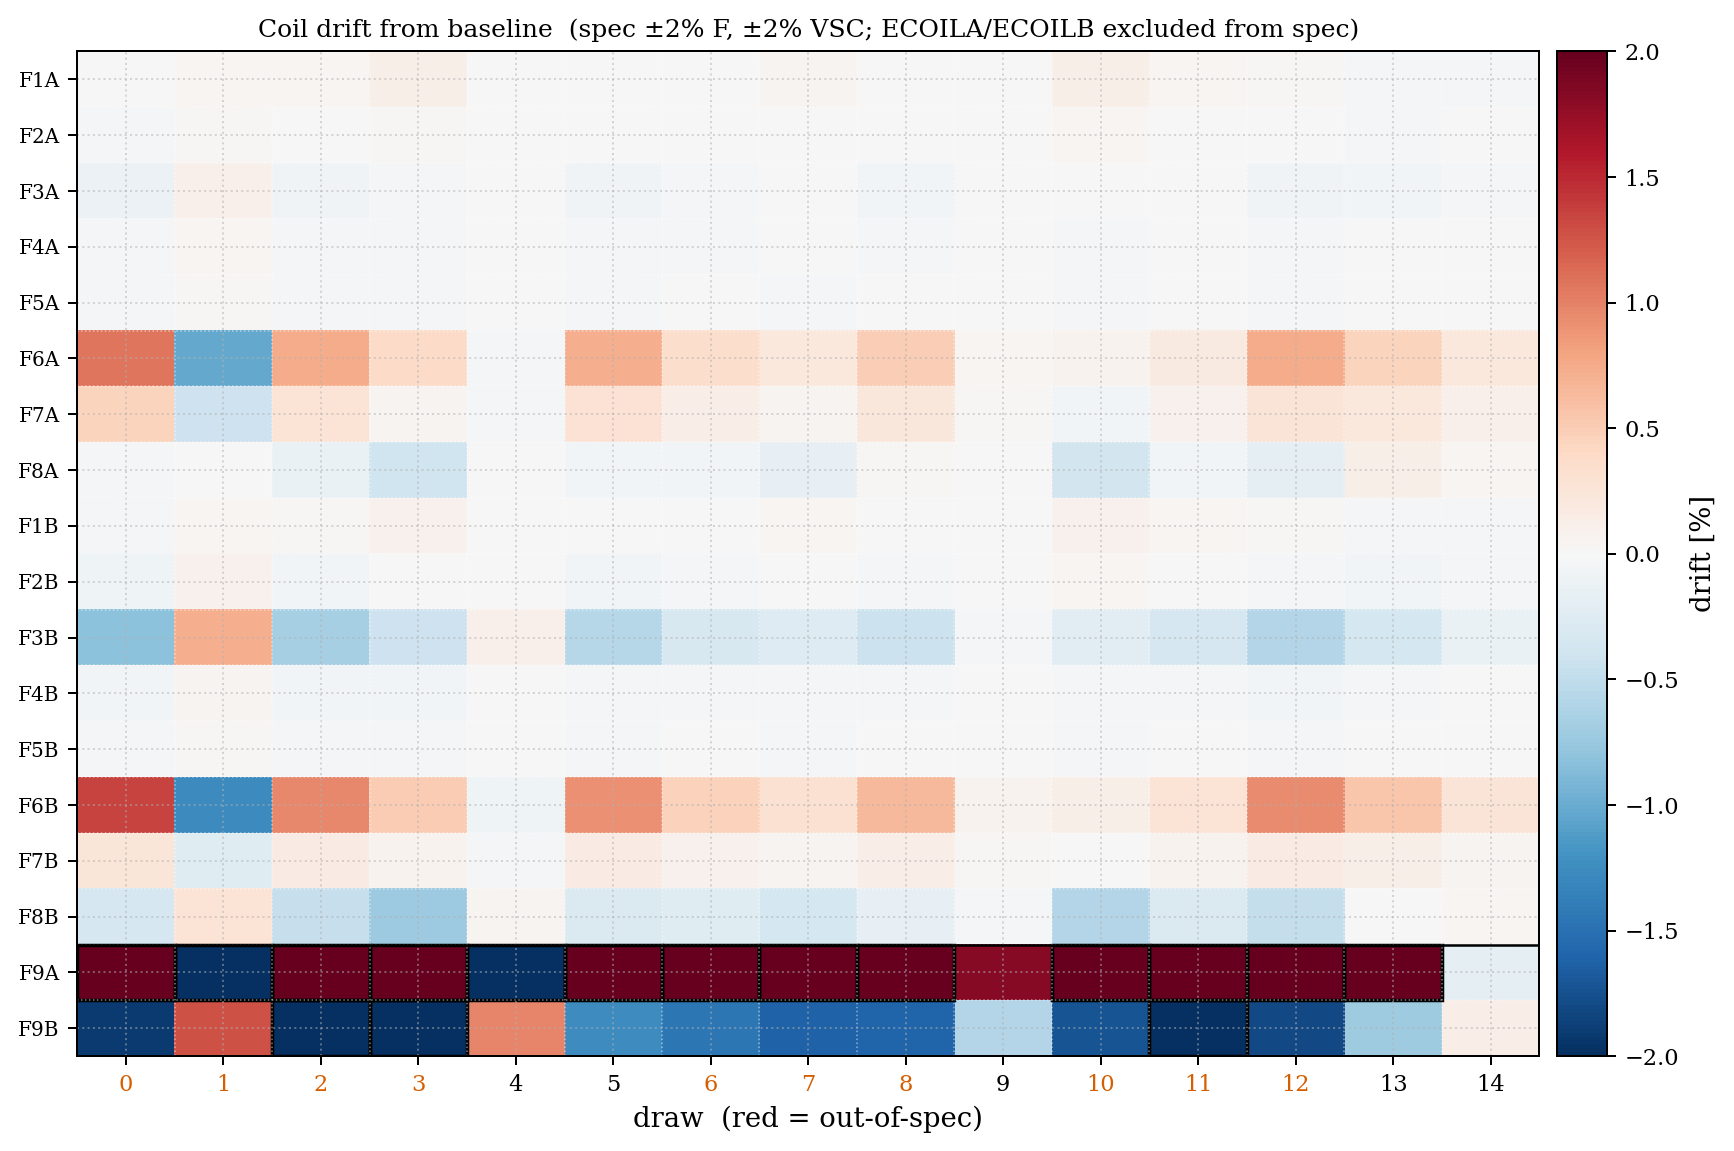

In [9]:
# plot_coil_currents flags: vsc_coils=('F9A','F9B')  exclude_coils=('ECOILA','ECOILB')  annotate={None(auto)|T|F}
# per-coil drift heatmap: saturated = at/over spec, black edge = violation,
# red draw label = out-of-spec draw, VSC pair below the rule
bq.plot_coil_currents(HEADER + '.h5', scan_key=2000); plt.show()


### The in-spec filter

`run.filter()` already screened the draws; here is what it did. **Coil-current
filter** — the binding constraint: a draw passes only if every non-VSC F-coil
stays within ±2 % of baseline (and the VSC pair within its own limit).
**Boundary filter** — rejects draws whose LCFS strays too far (RMS, mm).
`selected` is the AND of both; `export()` wrote the selected-only file.

`plot_spec_summary` shows the whole story at once: each draw's **fraction of
spec** for both criteria (1.0 = exactly at spec), and the **spec box** — where
every draw lands relative to both limits simultaneously.


coil-current in-spec: 5/15 (10 out-of-spec)
boundary RMS [mm]: median 2.34  95th 3.36  max 3.87
selected (deliverable): 5 draws [4, 5, 9, 13, 14]
excluded (out-of-spec): 10 draws [0, 1, 2, 3, 6, 7, 8, 10, 11, 12]


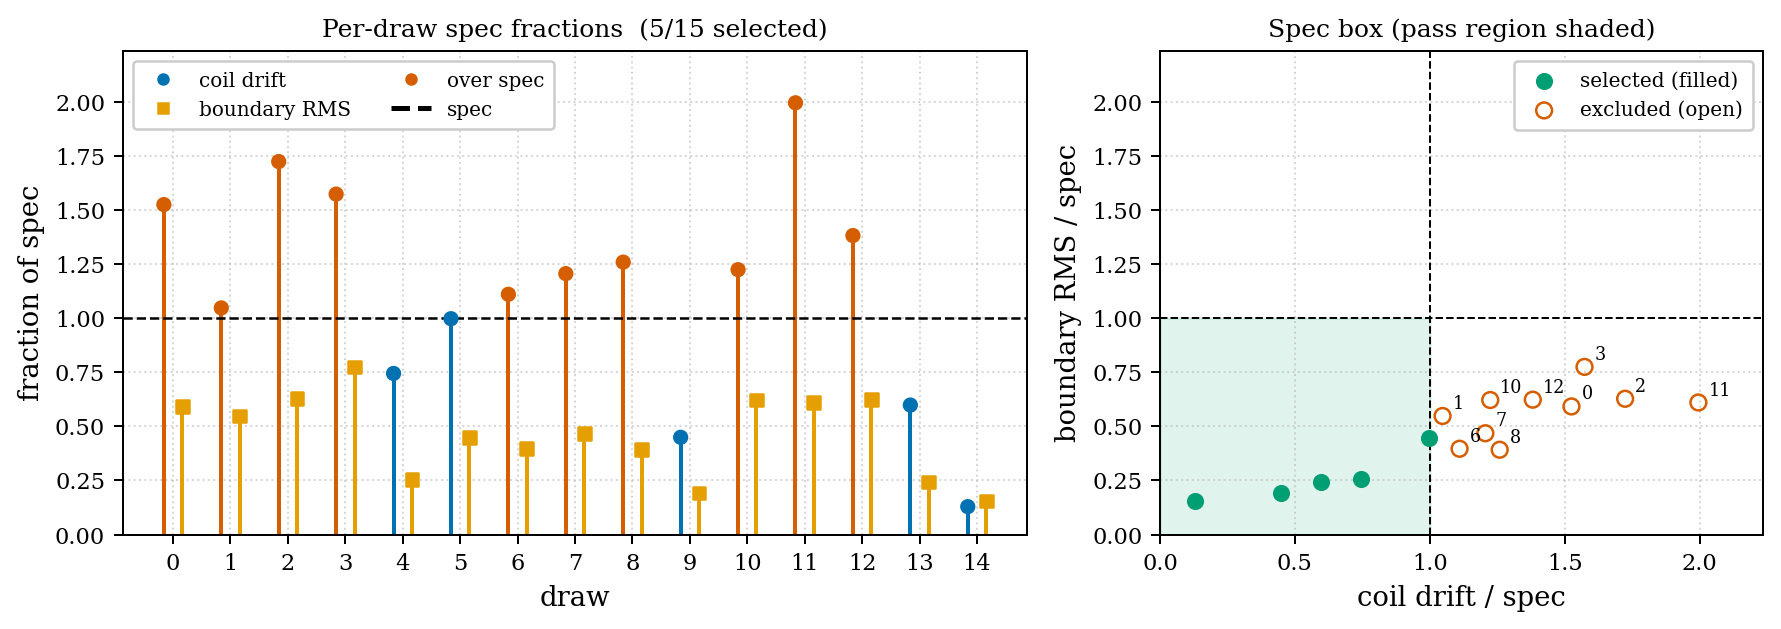

at rms_max_mm=1.5, 11/15 draws would be excluded: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12]


In [10]:
# filter_coil_currents flags: F_max_pct  VSC_max_pct  apply={T|F}  plot={T|F}
cs, _ = bq.filter_coil_currents(HEADER, scan_key=2000, plot=False)
print(f"coil-current in-spec: {cs['n_pass']}/{cs['n_total']} "
      f"({cs['n_fail']} out-of-spec)")
# filter_boundaries flags: rms_max_mm  max_max_mm  apply={T|F}  plot={T|F}
bs, _ = bq.filter_boundaries(HEADER, rms_max_mm=5.0, scan_key=2000, plot=False)
rs = bs['rms_stats']
print(f"boundary RMS [mm]: median {rs['median']:.2f}  95th {rs['p95']:.2f}  max {rs['max']:.2f}")
# select_indices flags: selection={selected|all|excluded}
sel = bq.select_indices(HEADER, scan_key=2000, selection='selected')
exc = bq.select_indices(HEADER, scan_key=2000, selection='excluded')
print(f"selected (deliverable): {len(sel)} draws {sel}")
print(f"excluded (out-of-spec): {len(exc)} draws {exc}")

# plot_spec_summary flags: rms_max_mm
bq.plot_spec_summary(HEADER, scan_key=2000, rms_max_mm=5.0); plt.show()

# What-if: re-screen at a tighter boundary spec WITHOUT writing flags
# (apply=False). The coil spec is hardware (±2%); the boundary cut is an
# analysis choice, so it is the natural knob to tighten.
bs_tight, _ = bq.filter_boundaries(HEADER, rms_max_mm=1.5, scan_key=2000,
                                apply=False, plot=False)
would_fail = sorted(i for i, d in bs_tight['draws'].items() if not d['passes'])
print(f"at rms_max_mm=1.5, {len(would_fail)}/{bs_tight['n_total']} draws "
      f"would be excluded: {would_fail}")


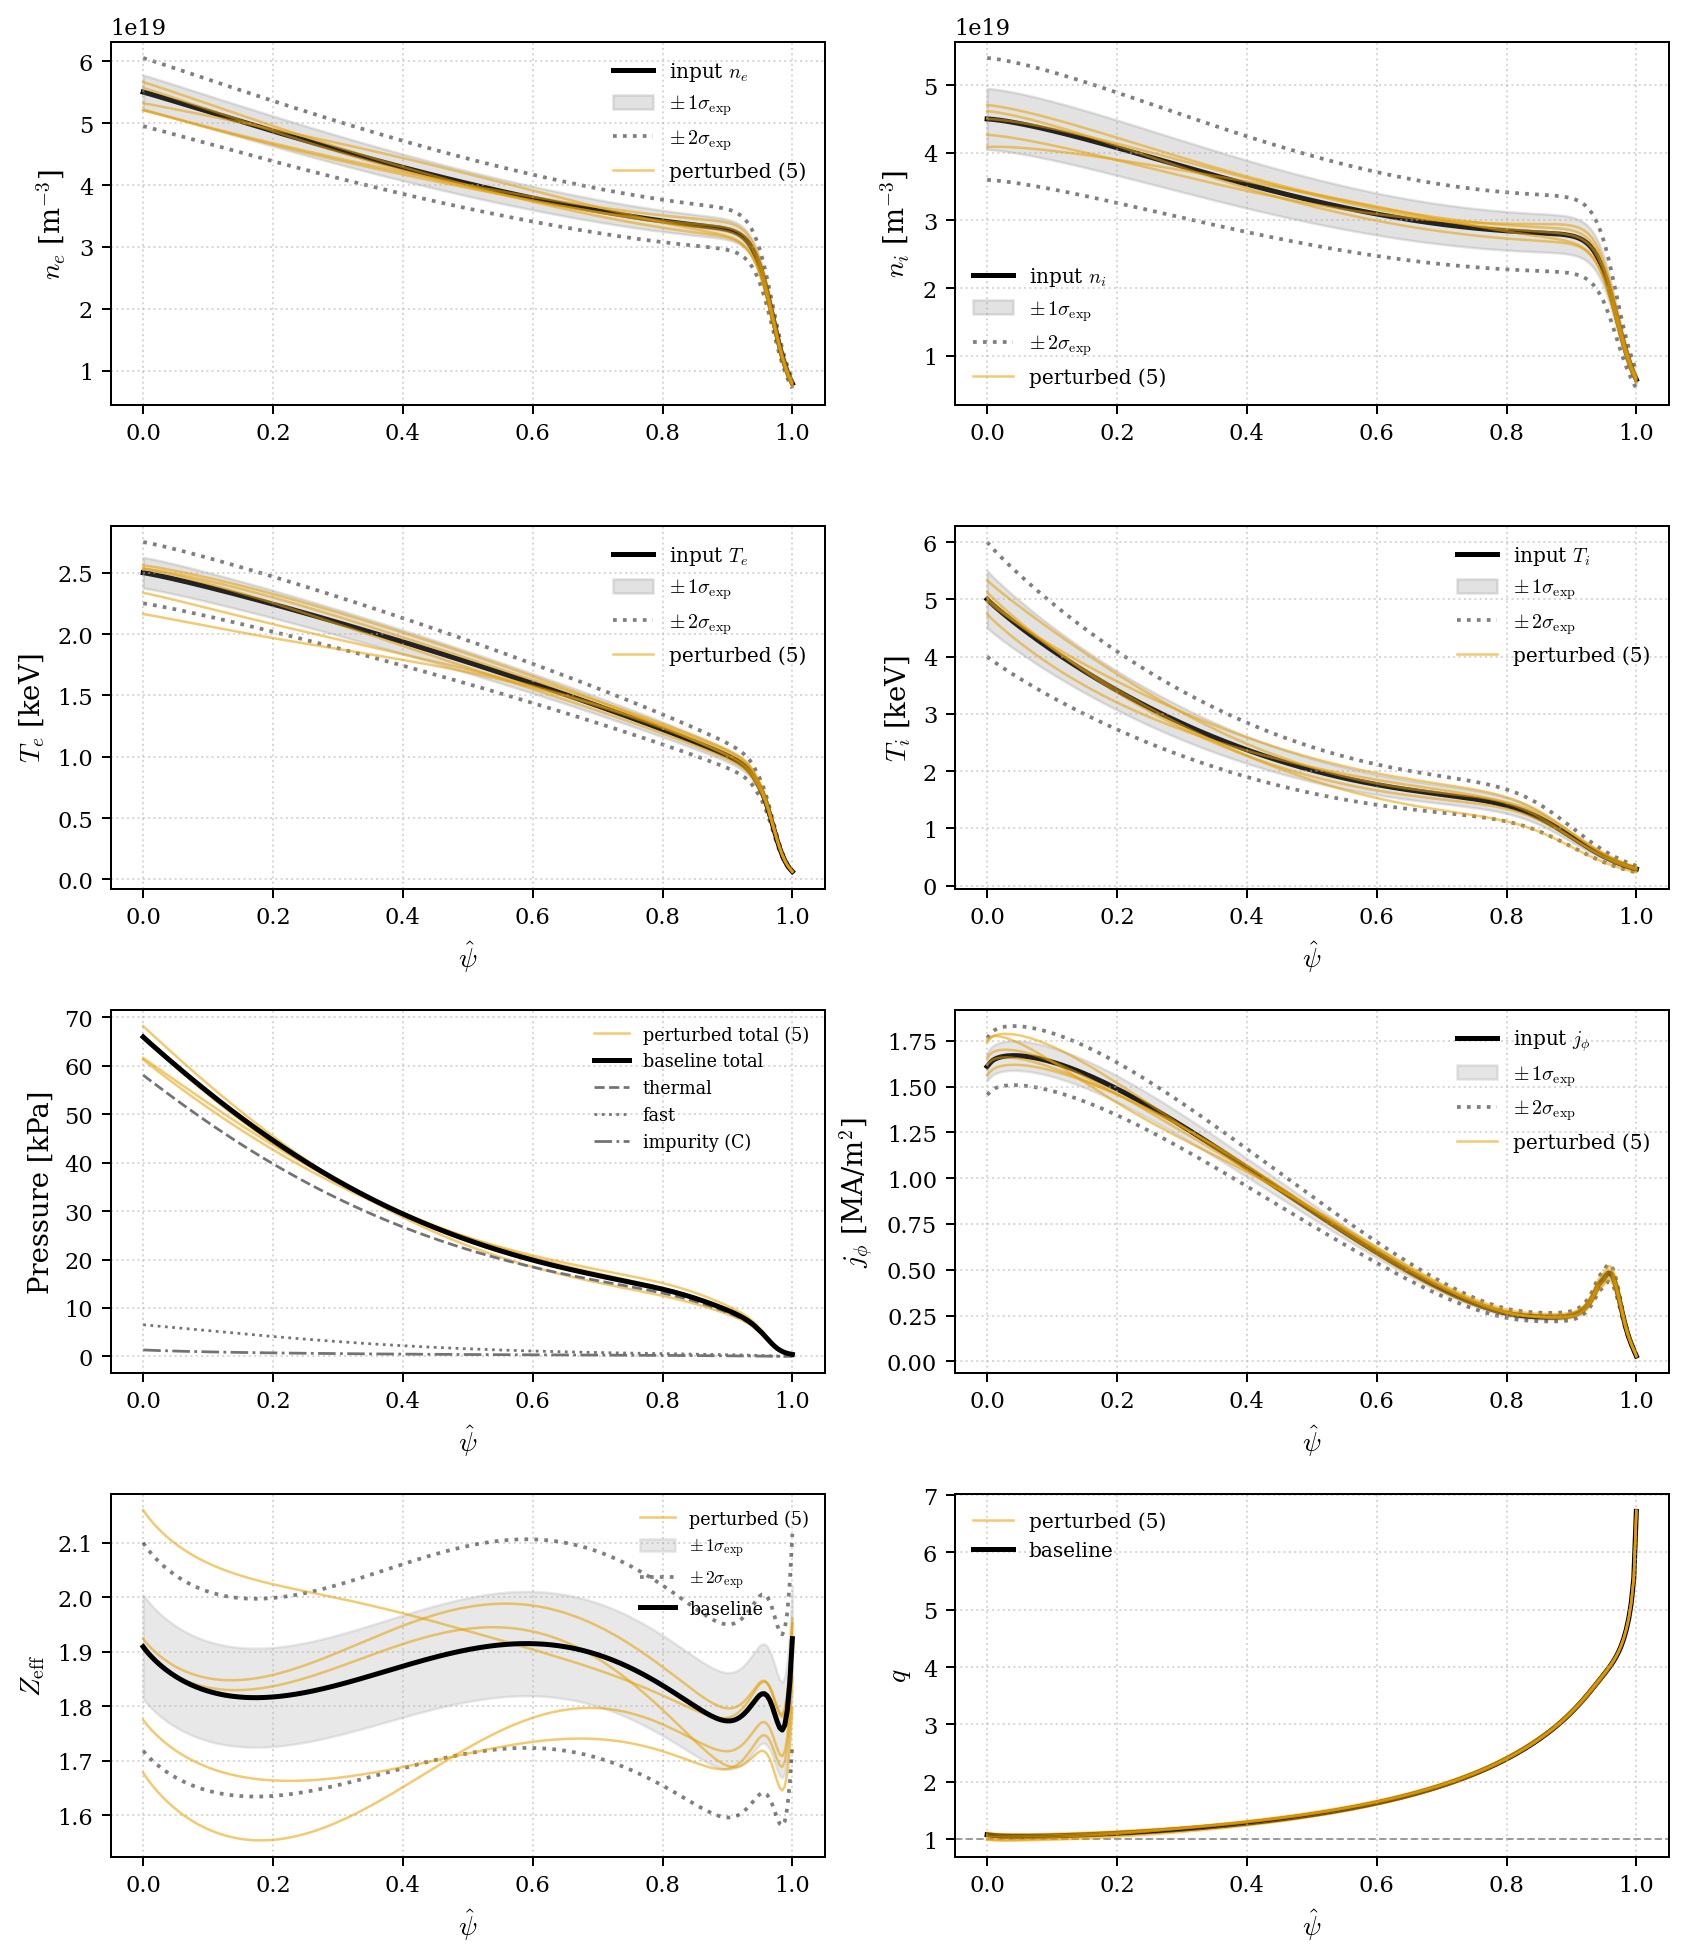

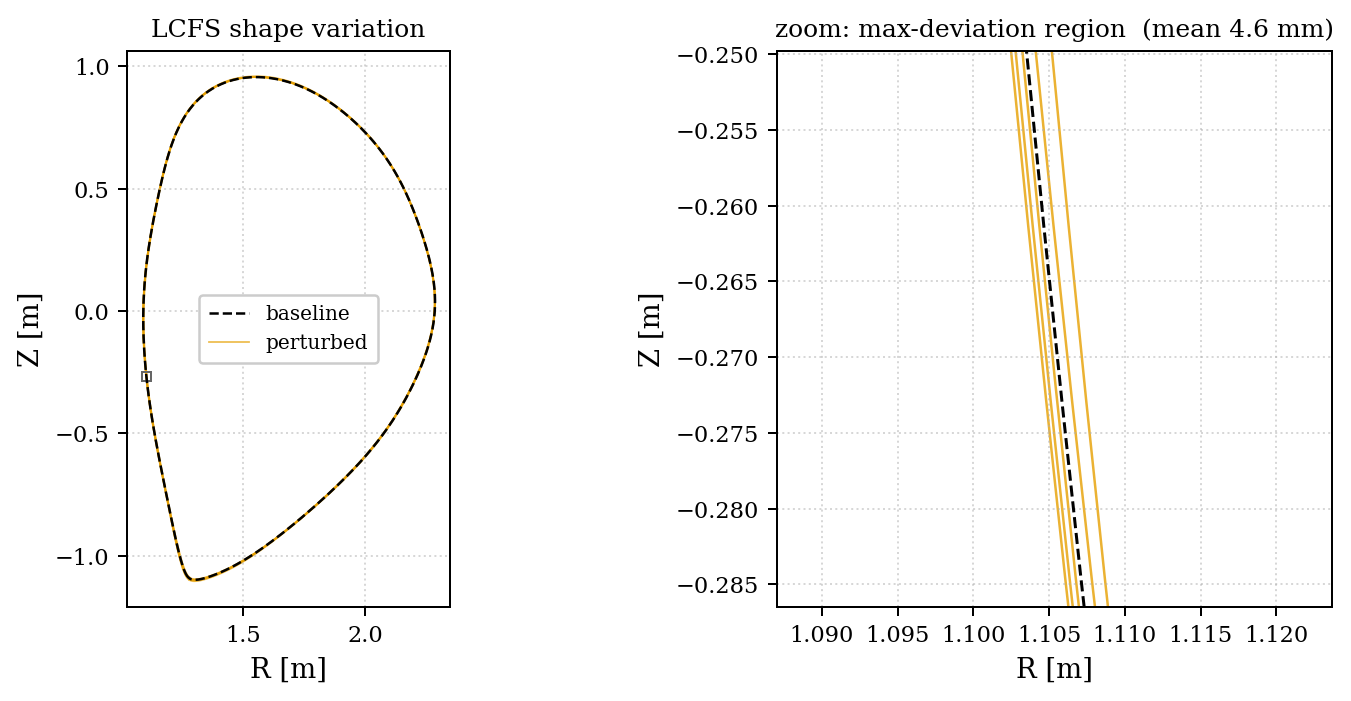

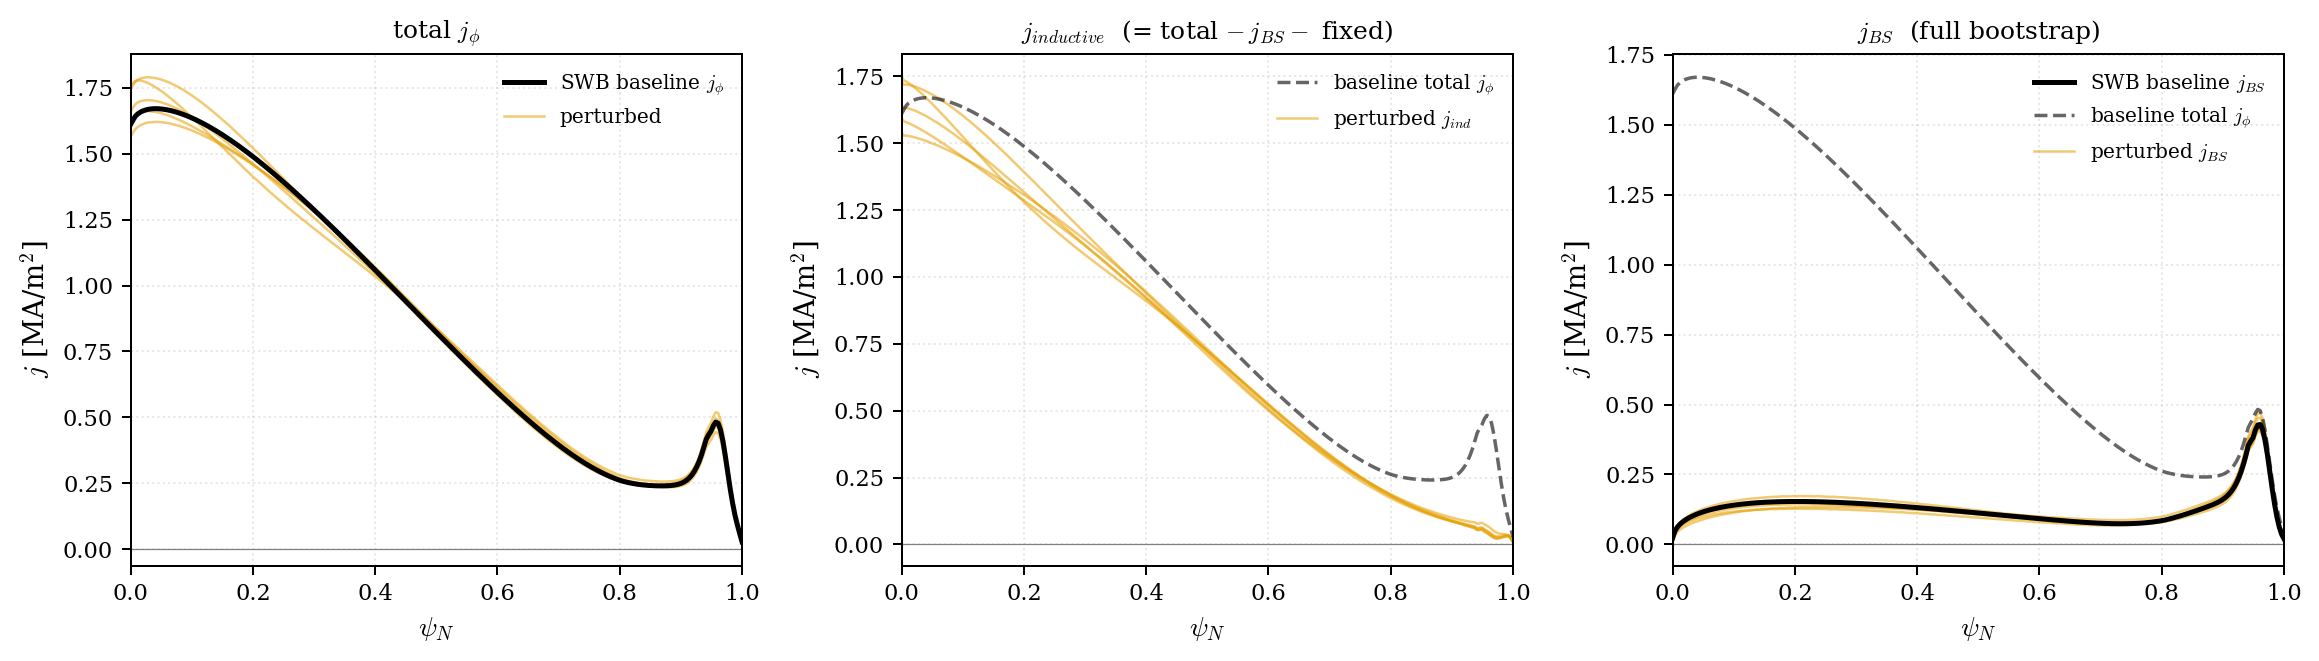

In [11]:
# the bouquet keeping ONLY the in-spec family
bq.plot_bouquet(HEADER + '.h5', scan_key=2000, mode='all', selection='selected');


## 4. ψ-dependent σ profiles (IDA-like)

Flat fractions are a starting point; real diagnostics have **ψ-dependent**
uncertainty — typically worse at the pedestal. `synthetic_ida_sigma(ψ, channel)`
is a deterministic, non-proprietary envelope calibrated to a real DIII-D IDA
analysis. Supplying `uncertainty.sigma_profiles` (absolute σ on the kinetic
grid) overrides the flat scalars per channel for n_e/T_e/T_i. (n_i is derived
from Z_eff, so its envelope follows n_e and Z_eff rather than a standalone σ.)


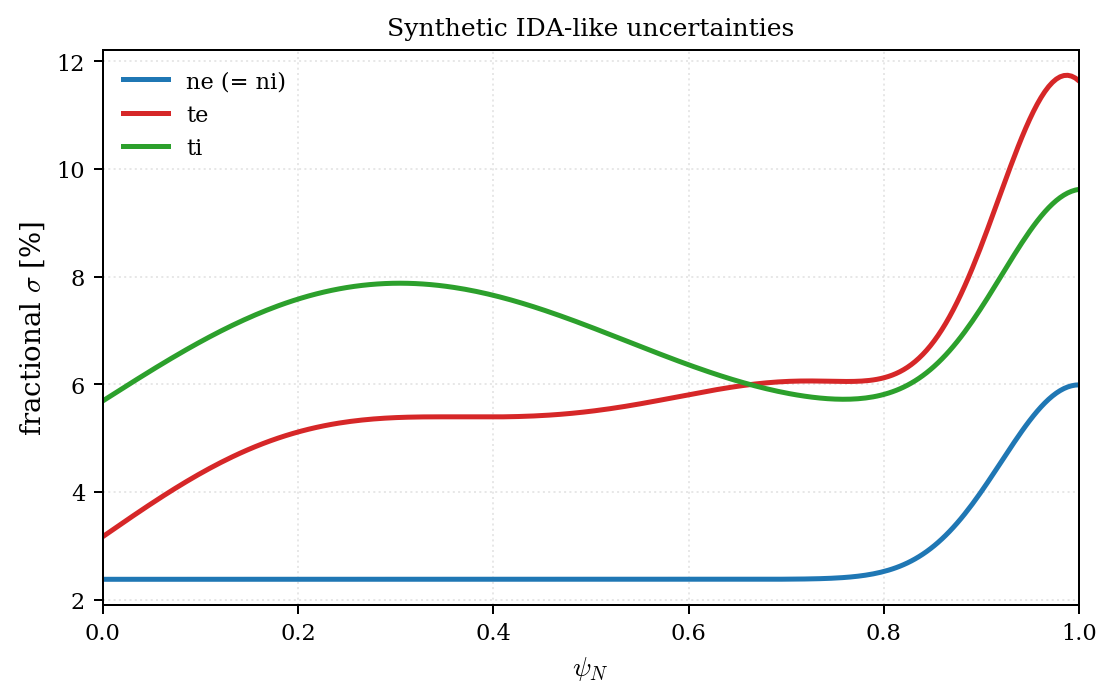

ψ-dependent σ profiles set for ['ne', 'te', 'ni', 'ti']


In [12]:
pk = run.baseline.psi_N_kinetic
# fractional envelopes, for a quick look (ni ≡ ne, so three distinct curves)
fig, ax = plt.subplots(figsize=(7, 4))
for ch, col in [('ne', 'tab:blue'), ('te', 'tab:red'), ('ti', 'tab:green')]:
    ax.plot(pk, bq.synthetic_ida_sigma(pk, ch) * 100, color=col, lw=2,
            label=ch + (' (= ni)' if ch == 'ne' else ''))
ax.set_xlabel(r'$\psi_N$'); ax.set_ylabel(r'fractional $\sigma$ [%]'); ax.set_xlim(0, 1)
ax.grid(alpha=0.3); ax.legend(); ax.set_title('Synthetic IDA-like uncertainties'); plt.show()

# absolute σ profiles -> override the flat scalars
run.uncertainty.sigma_profiles = {
    'ne': bq.synthetic_ida_sigma(pk, 'ne') * run.baseline.ne,
    'te': bq.synthetic_ida_sigma(pk, 'te') * run.baseline.te,
    'ni': bq.synthetic_ida_sigma(pk, 'ni') * run.baseline.ni,
    'ti': bq.synthetic_ida_sigma(pk, 'ti') * run.baseline.ti,
}
print('ψ-dependent σ profiles set for', list(run.uncertainty.sigma_profiles))


## 5. Auxiliary profiles (the switchboard) — and every knob in one place

The Z_eff channel is already on (§2). The **switchboard** is the general
mechanism behind it: supplying a σ on the kinetic grid enables perturbation of a
named auxiliary channel. Beyond `zeff` you can add rotation (`omega_tor`,
`e_r`) and transport (`chi_e`, `chi_i`). **On the IMAS path these baselines are
auto-filled from the IDS** (`run.baseline.aux`, listed in §1), so you only
supply the σ — no manual baselines, unlike the reconstruction notebook.

`zeff` is the *active* channel — each draw samples Z_eff and **derives** n_i via
quasineutrality (Z_imp from the IDS species), one mutually consistent (n_e, n_i,
Z_eff, n_z) set per draw. Here we widen its envelope and add the *passive*
rotation/transport channels (perturbed and archived, not GS inputs).

The cell after that is a **look-up table of every knob on the driver**, each set
to the value this notebook runs with — edit any of them and re-run `generate()`.


In [13]:
a = run.baseline.aux or {}   # IDS-provided baselines (omega_tor, e_r, chi_e, chi_i, zeff)
# IMAS auto-fills aux_baselines from the IDS; we only supply σ to enable a channel
run.uncertainty.aux_sigmas = {
    'omega_tor': 0.10*np.abs(a['omega_tor']),    # ±10%  (passive)
    'e_r':       0.10*np.abs(a['e_r']) + 1e2,
    'chi_e':     0.20*a['chi_e'],                # ±20%
    'chi_i':     0.20*a['chi_i'],
    'zeff':      0.05*a['zeff'],                 # explicit σ (ACTIVE -> bootstrap + derived n_i)
}
print('aux channels enabled:', list(run.uncertainty.aux_sigmas))


aux channels enabled: ['omega_tor', 'e_r', 'chi_e', 'chi_i', 'zeff']


In [14]:
# ── Knob reference: everything tunable on the driver ─────────────────────
# Grouped by config block; every value below is what this notebook runs with.

# — source (IMAS path) —
run.source.time       = TIME     # time slice [s] (set_slice() re-points without re-solving)
run.source.occurrence = 0        # IDS occurrence index
# NOTE: no impurity_Z knob -- the IMAS path takes the impurity mix (Z_imp) from
# the IDS species list directly. The g-file path uses ReconstructionSource.impurity_Z.

# — solver —
# nthreads is intentionally left at its default of 1. Do NOT raise it:
# TokaMaker's OpenMP threads oversubscribe numpy's BLAS and make draws
# SLOWER (~3x), not faster. Use bouquet.parallel for multi-core (one
# BLAS-pinned worker per process).
run.solver.order    = 3          # FE order (2 = faster, 3 & 4 = higher accuracy)
run.solver.F0       = None       # vacuum R*Bt override (None -> from the IDS B0)

# — uncertainty envelope —
# kinetic σ precedence per channel: sigma_profiles (§4) > scalars
run.uncertainty.ne_scalar_sigma   = 0.05   # flat fractional σ fallbacks
run.uncertainty.te_scalar_sigma   = 0.05
run.uncertainty.ni_scalar_sigma   = 0.10   # ions: harder to diagnose
                                           #   (unused while the zeff channel
                                           #    is active: n_i is derived)
run.uncertainty.ti_scalar_sigma   = 0.10
run.uncertainty.jphi_scalar_sigma = 0.05   # fractional σ on |j_phi|
run.uncertainty.zeff_scalar_sigma = 0.05   # ENABLES the Z_eff channel (0.0 = off,
                                           #   then n_i drawn independently)
run.uncertainty.n_ls = 0.5                 # GPR correlation lengths [ψ_N]:
run.uncertainty.t_ls = 0.4                 #   smaller = wigglier draws
run.uncertainty.j_ls = 0.25
# aux_sigmas: the auxiliary channels (cell above); IMAS auto-fills aux_baselines.
# aux_length_scales: per-channel GPR length, default 0.4 when unset

# — generation —
run.generation.n_equils           = 15      # draws per run
run.generation.seed               = 42     # GPR reproducibility (solver: see nthreads)
run.generation.l_i_tolerance      = 0.05   # l_i acceptance band (FRACTION of target)
run.generation.constrain_sawteeth = False  # reject draws with q0 < 1
run.generation.recalculate_j_BS   = True   # per-draw Redl bootstrap (else keep IDS j_BS)
run.generation.jBS_scale_range    = (0.95, 1.05)  # multiplicative j_BS spread per draw
                                           #   (±5%, coarse Sauter/Redl model uncertainty;
                                           #    ±10% (0.9,1.1) stresses yield + core offset)
run.generation.swb_iterations     = 3      # bootstrap self-consistency iterations (2 = faster)
run.generation.coil_drift         = 0.01   # final hard per-coil drift bound (fraction)
run.generation.homotopy_passes    = [(0.05, 0.10), (0.02, 0.05), (0.01, 0.01)]
                                           # (F, VSC) bound schedule, loose -> tight
run.generation.diagnostic_plots   = False  # per-draw solver figures (debug)

# — filtering (the in-spec screen of §3) —
run.filtering.inspec_F_max   = 0.02   # non-VSC F-coil spec (±2%, DIII-D hardware)
run.filtering.inspec_VSC_max = 0.02   # VSC-pair spec
run.filtering.rms_max_mm     = 5.0    # LCFS RMS cut [mm] (analysis choice)

# — output —
run.config.verbose = False   # stream solver chatter (else captured to *_log)
print('knob reference applied — values match the run above unless edited')

knob reference applied — values match the run above unless edited


## 6. Comprehensive re-run + outputs

Now generate again with the ψ-dependent σ **and** the switchboard active. The
solver and baseline are reused (no re-solve of the baseline); we just write to a
new file and re-screen. `plot_bouquet(mode='all')` now also shows the perturbed
auxiliary profiles (with their input baseline and ±1σ/±2σ envelopes).


In [15]:
HEADER_FULL = HEADER + '_full'
run.config.output_header = HEADER_FULL
run.generate(); run.filter(); run.export()


  [sigma-source] sigma_ne   <- explicit sigma_profiles      (peak 1.503e+18)
  [sigma-source] sigma_te   <- explicit sigma_profiles      (peak 115.3)
  [sigma-source] sigma_ni   <- explicit sigma_profiles      (peak 1.263e+18)
  [sigma-source] sigma_ti   <- explicit sigma_profiles      (peak 284.5)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 8.069e+04)



=== Bouquet — D3Dlike_omas_t2.3043_full =========  9/14 in-spec (64%)
  draws         14 generated
  coil spec     9/14 within ±2%   (5 out-of-spec)
  boundary      RMS median 2.10 mm   max 3.51 mm


'D3Dlike_omas_t2.3043_full_selected.h5'

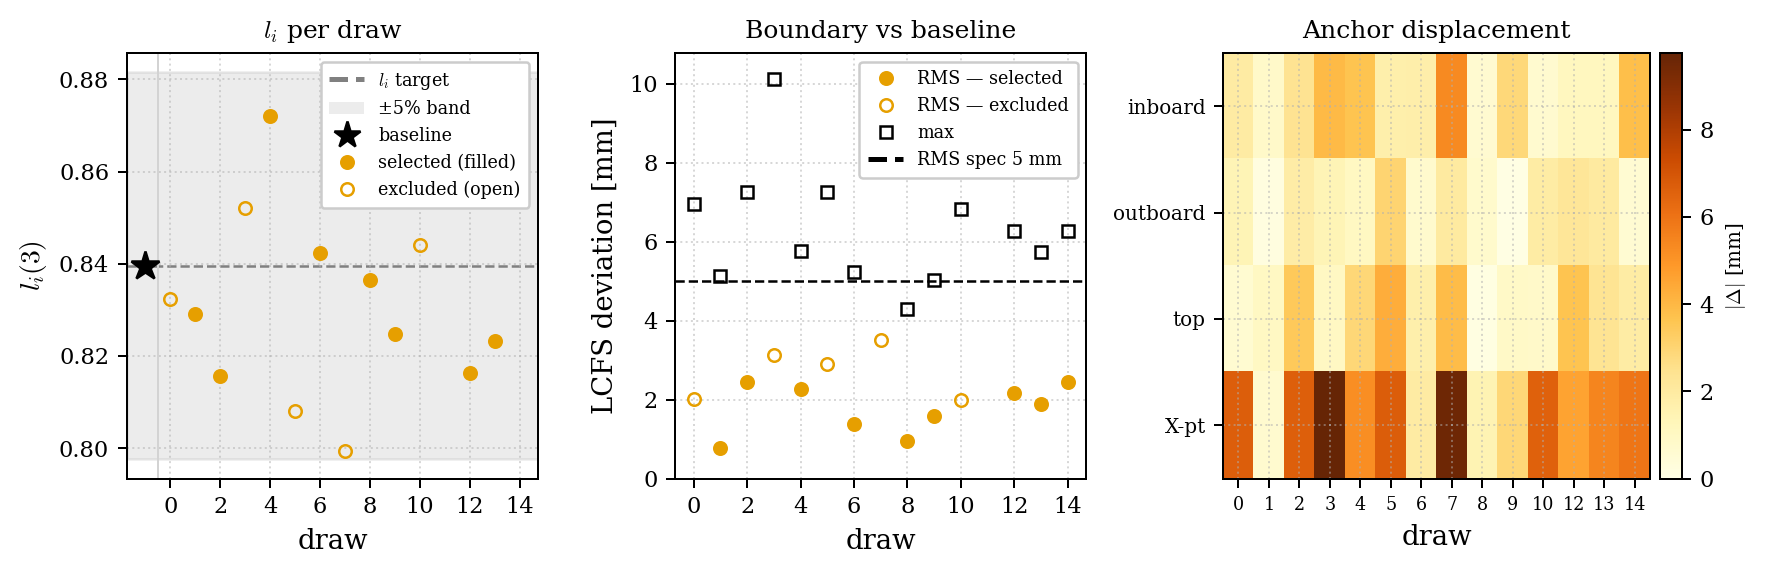

In [16]:
bq.plot_traces(HEADER_FULL + '.h5', scan_key=2000, li_band=run.generation.l_i_tolerance,
               rms_max_mm=run.filtering.rms_max_mm); plt.show()


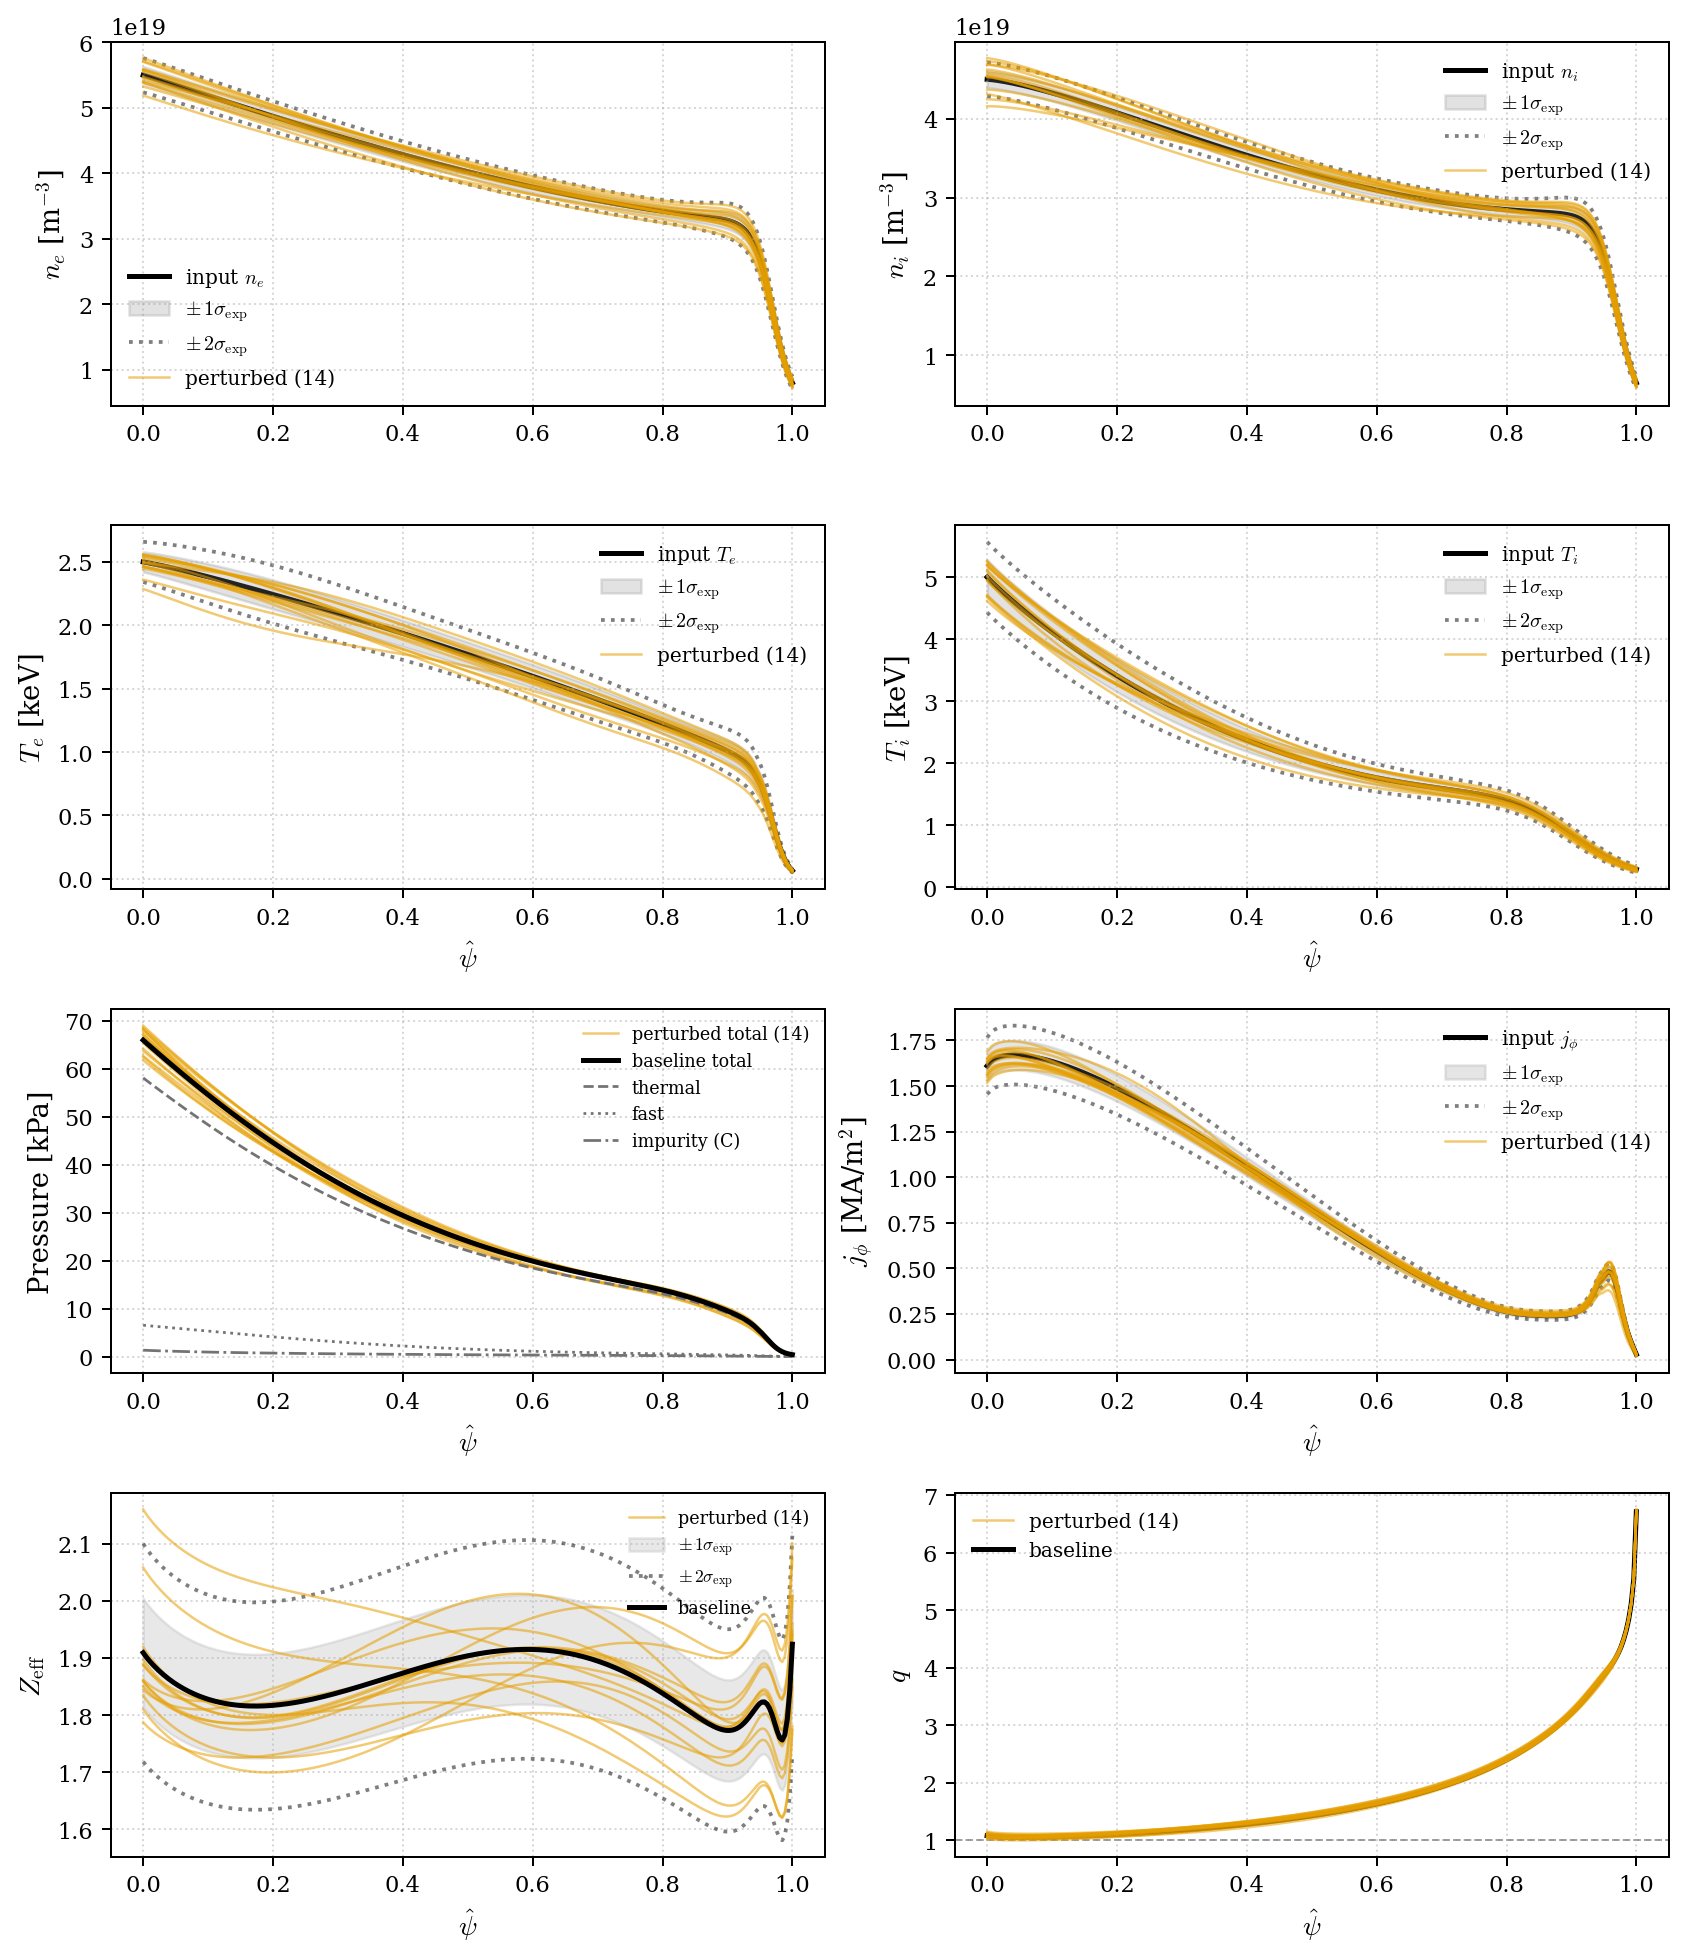

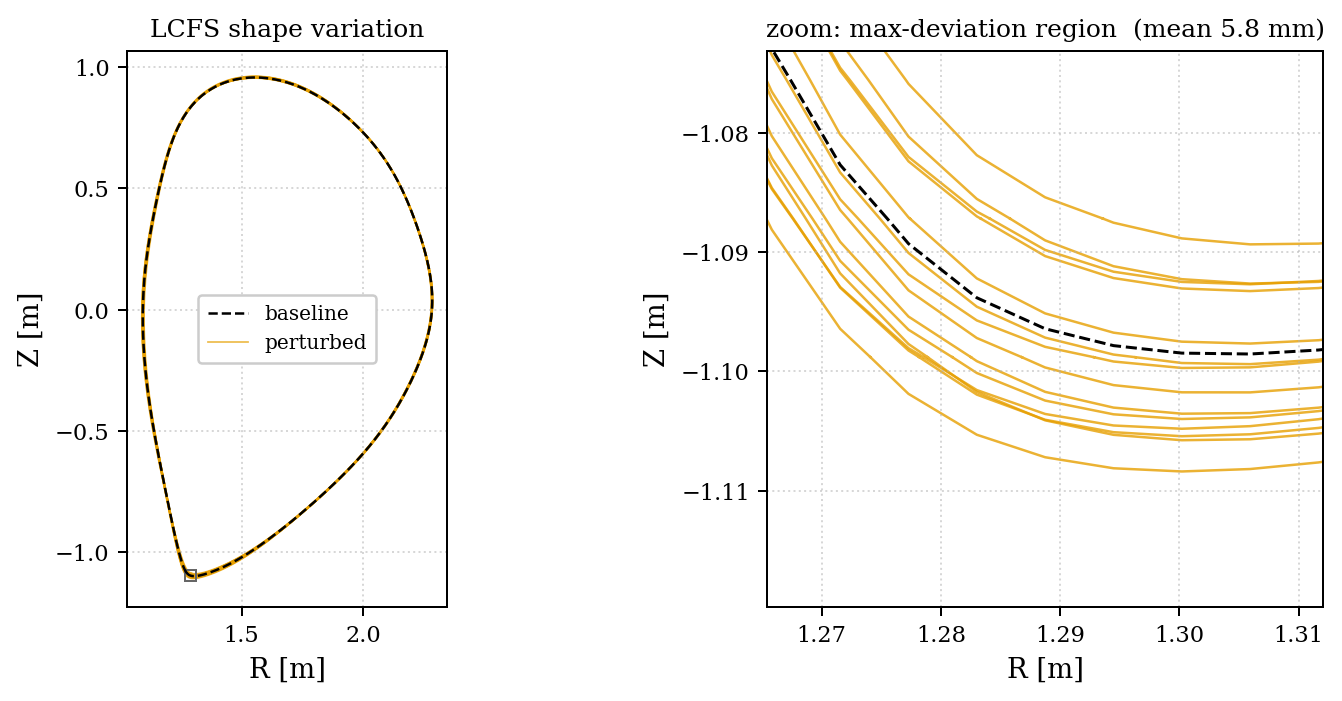

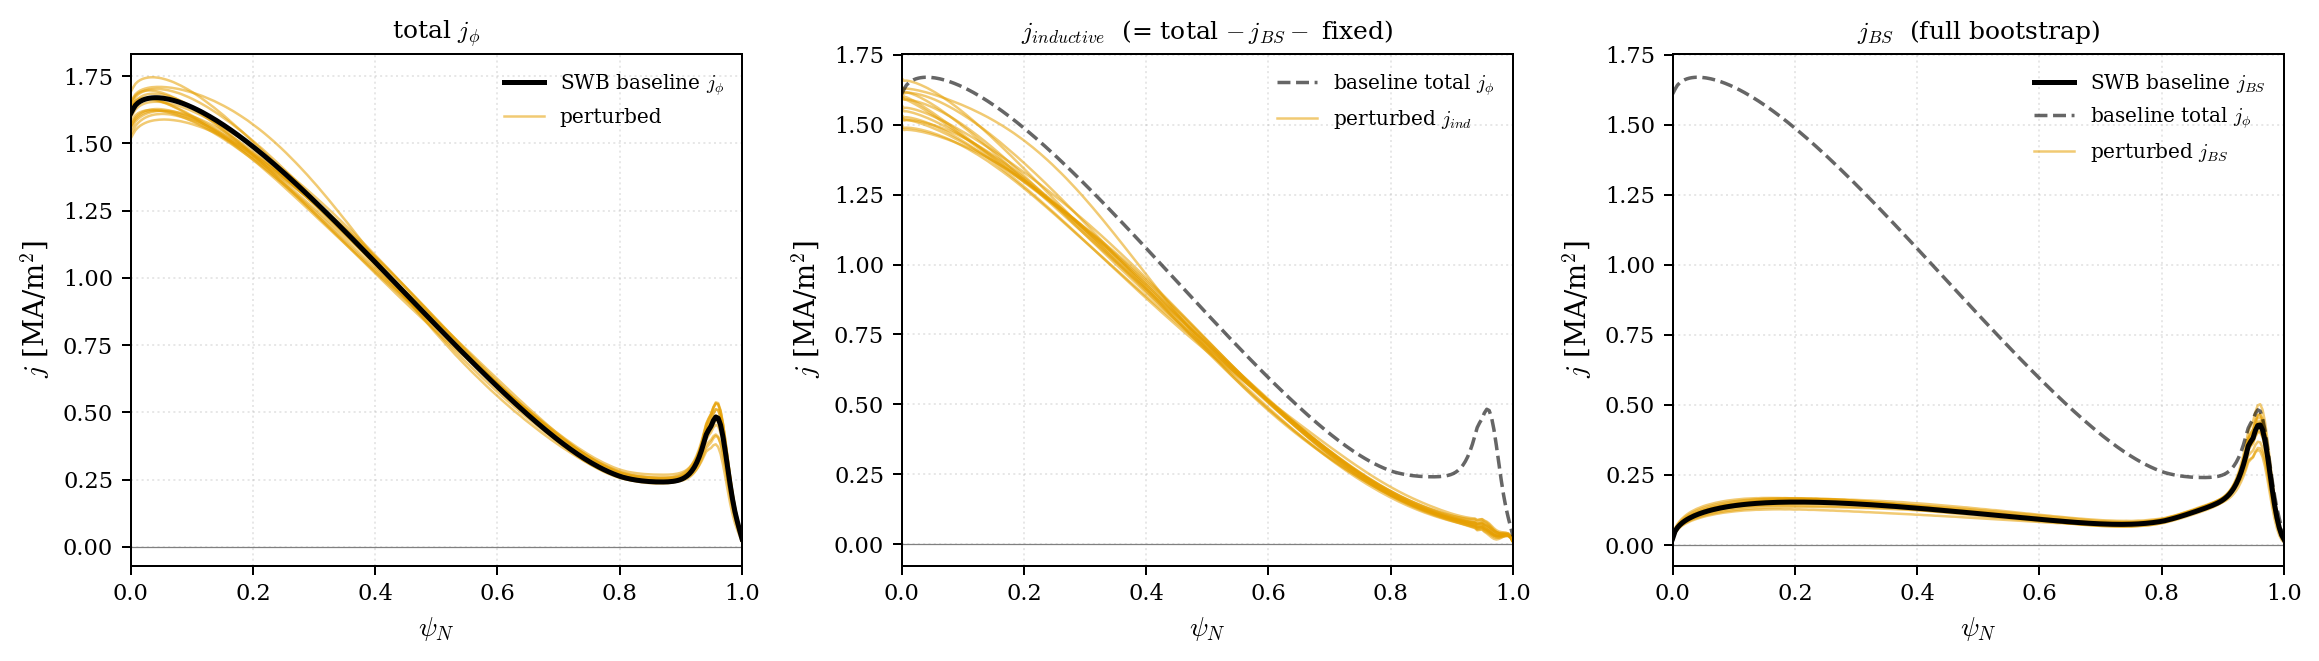

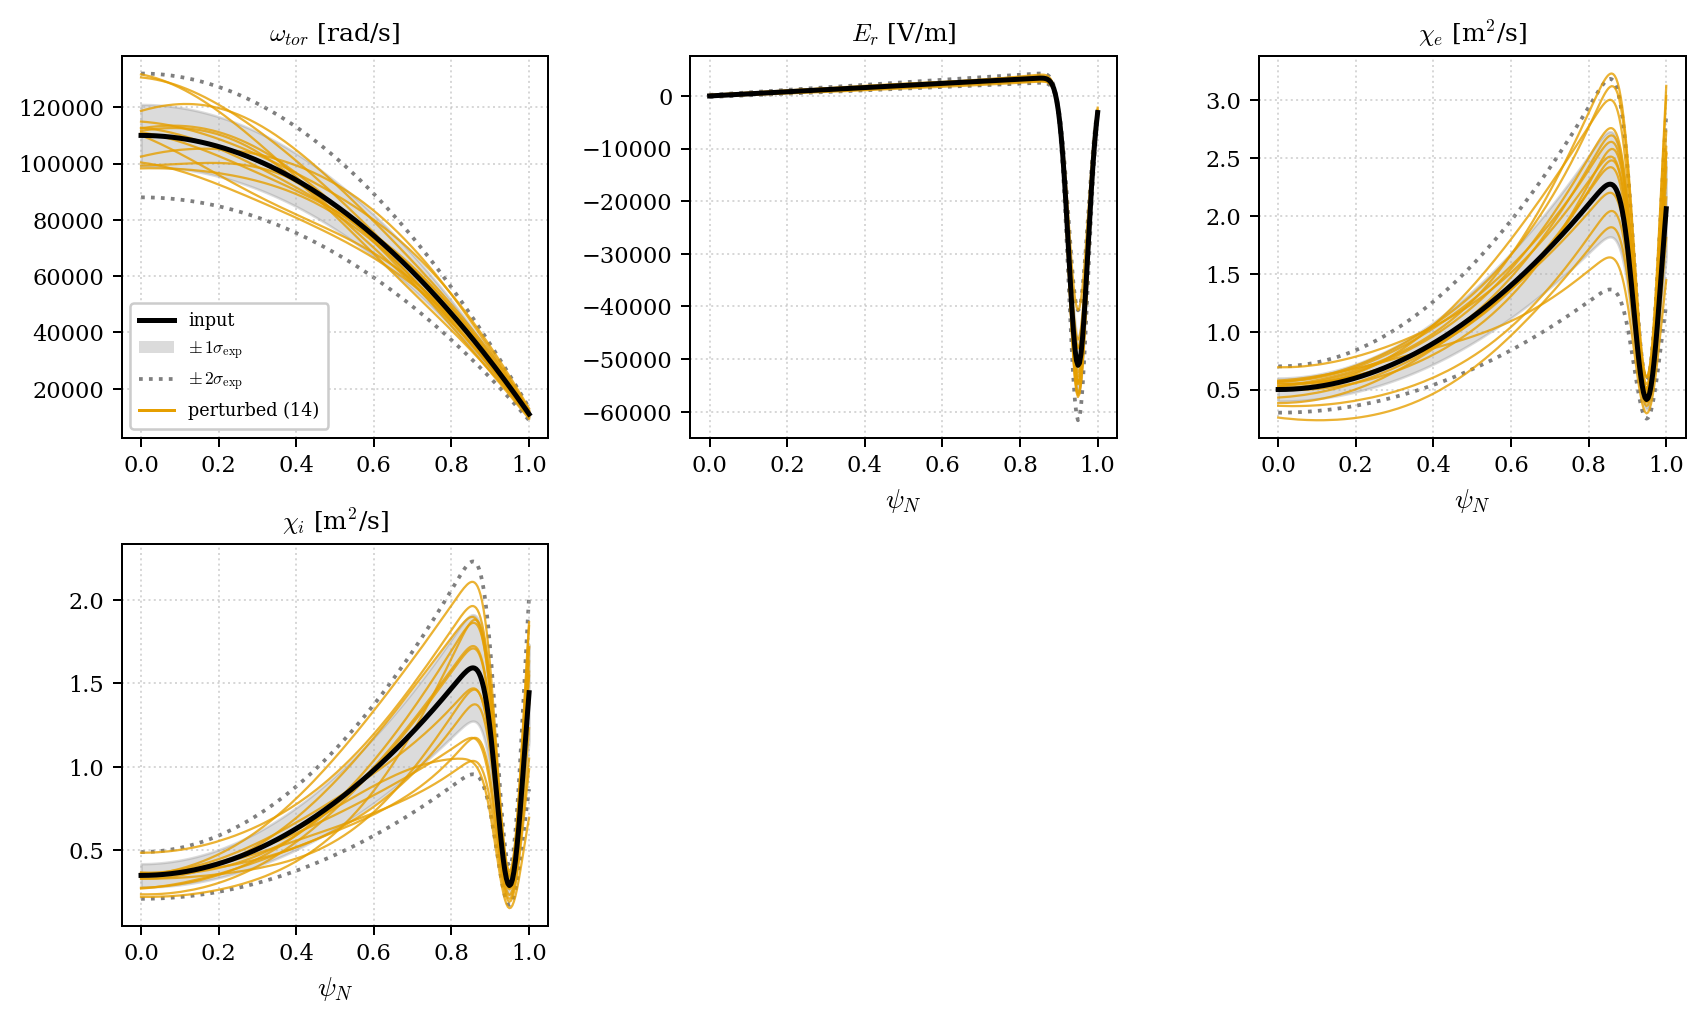

In [17]:
bq.plot_bouquet(HEADER_FULL + '.h5', scan_key=2000, mode='all');


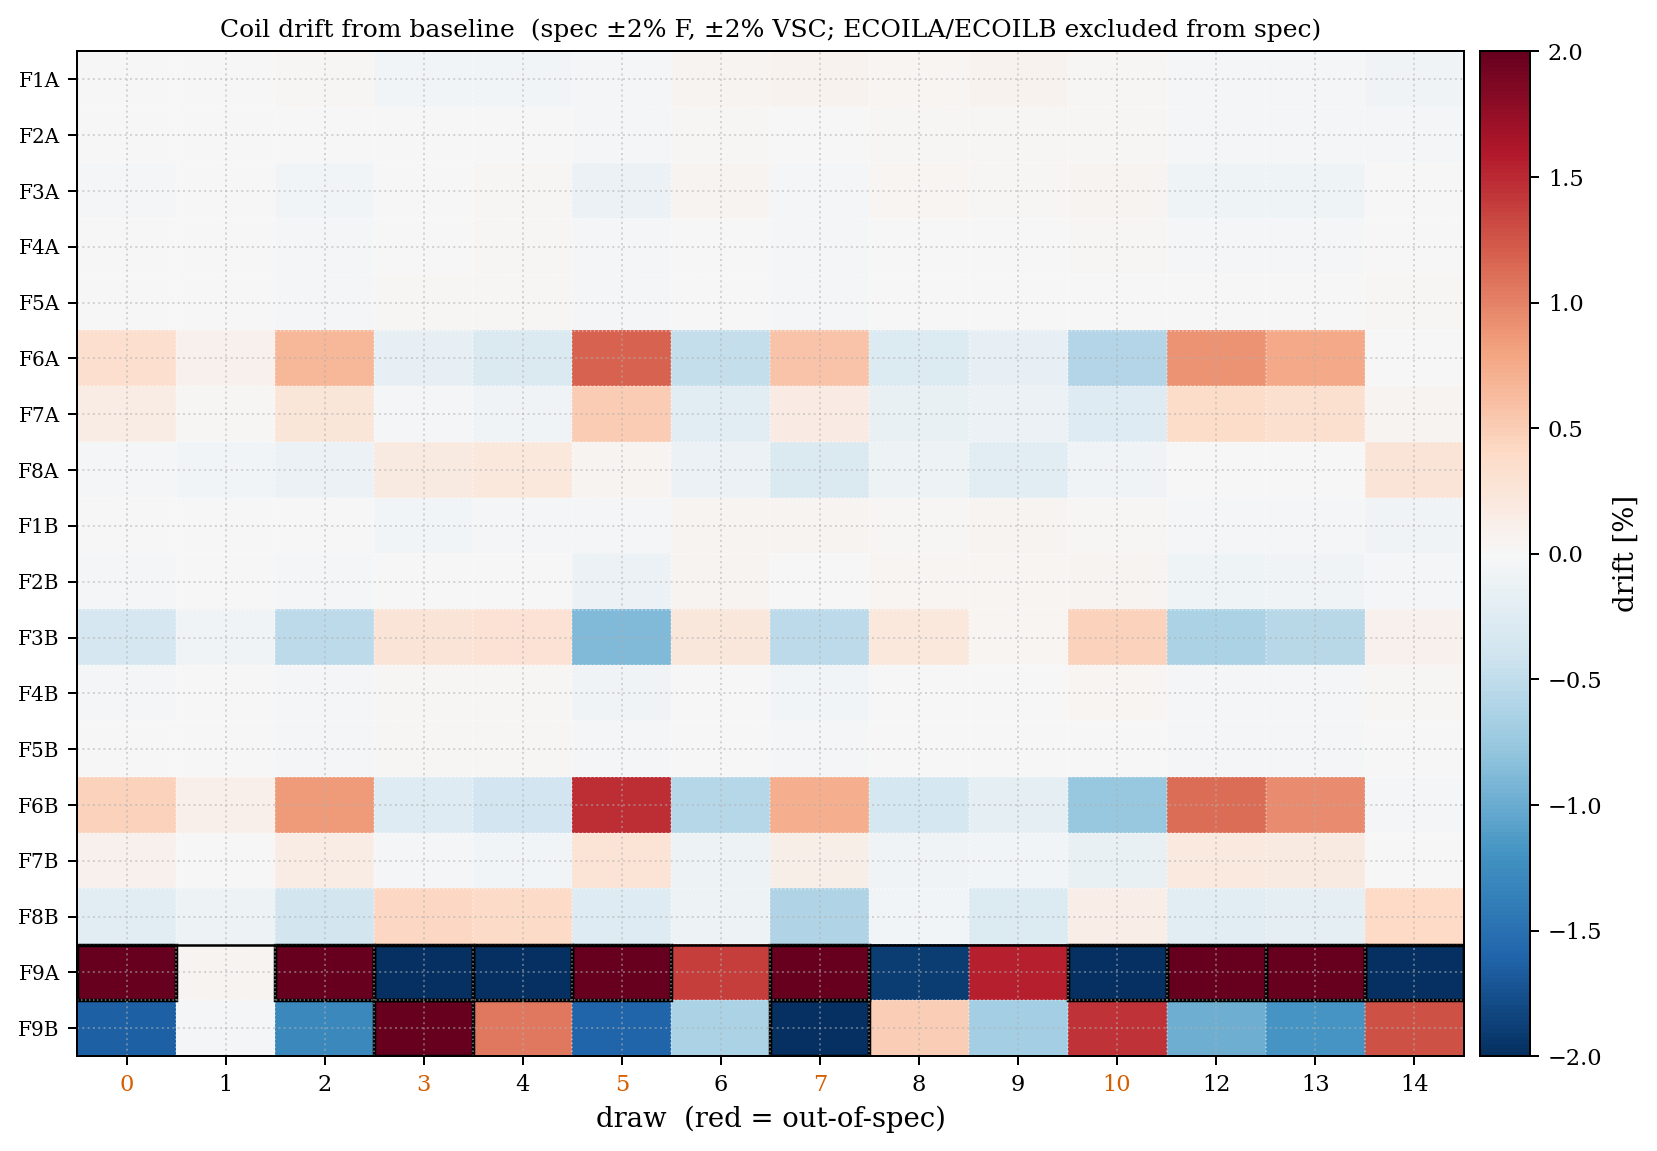

In [18]:
bq.plot_coil_currents(HEADER_FULL + '.h5', scan_key=2000); plt.show()


## 7. Time evolution — the 3-slice L→H transition

The dataset holds three slices of an EPED-like L→H ramp at **fixed plasma
current and fixed boundary shape**: the pedestal grows, bootstrap rises,
inductive current falls. Reading each slice's baseline is solve-free, so we
first overlay the baselines (colored by time).


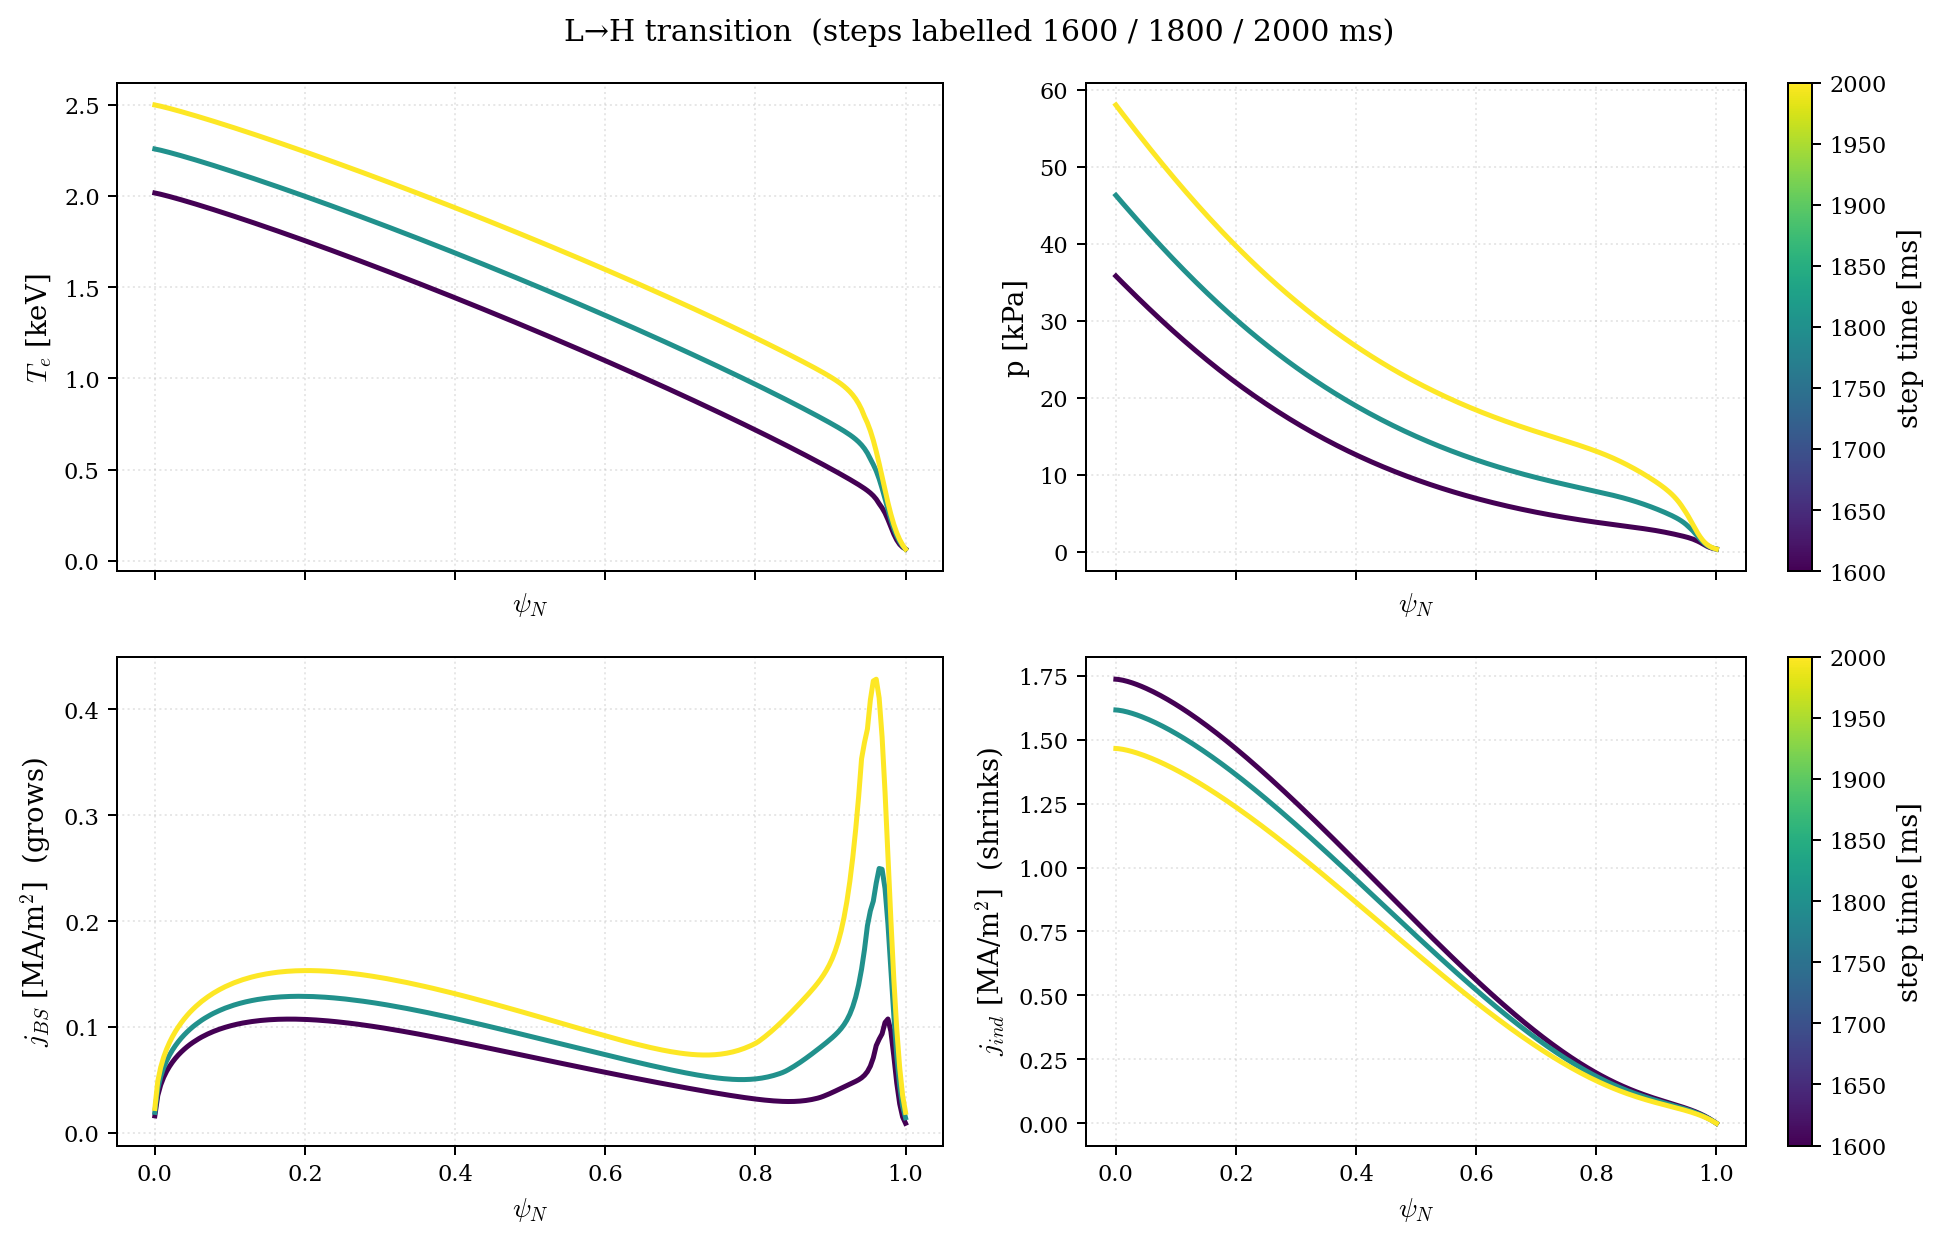

In [19]:
TIMES   = [2.10, 2.20, 2.3043]      # actual IDS slice times [s]
STEP_MS = [1600, 1800, 2000]        # fake L→H step labels [ms]
T2MS = dict(zip(TIMES, STEP_MS))
BLS = {t: bq.read_imas_baseline(bq.ImasSource(ids_path=OMAS, time=t)) for t in TIMES}
norm = mcolors.Normalize(vmin=min(STEP_MS), vmax=max(STEP_MS)); cmap = cm.viridis
def scol(t): return cmap(norm(T2MS[t]))
def sbar(ax, fig):
    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([]); fig.colorbar(sm, ax=ax, label='step time [ms]')
fig, ax = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for t in TIMES:
    b = BLS[t]
    ax[0,0].plot(b.psi_N, b.te/1e3, color=scol(t))
    ax[0,1].plot(b.psi_N, EC*(b.ne*b.te+b.ni*b.ti)/1e3, color=scol(t))
    ax[1,0].plot(b.psi_N, b.j_BS/1e6, color=scol(t))
    ax[1,1].plot(b.psi_N, b.j_inductive/1e6, color=scol(t))
ax[0,0].set_ylabel(r'$T_e$ [keV]'); ax[0,1].set_ylabel('p [kPa]')
ax[1,0].set_ylabel(r'$j_{BS}$ [MA/m$^2$]  (grows)'); ax[1,1].set_ylabel(r'$j_{ind}$ [MA/m$^2$]  (shrinks)')
for a in ax.flat: a.set_xlabel(r'$\psi_N$'); a.grid(alpha=0.3)
sbar(ax[0,1], fig); sbar(ax[1,1], fig)
fig.suptitle('L→H transition  (steps labelled 1600 / 1800 / 2000 ms)'); plt.tight_layout(); plt.show()


Now a **full bouquet at every slice**. The three slices share one LCFS boundary
(verified: Δ < 0.1 mm), so a single solver serves all of them — `set_slice`
re-points the driver to each time and re-solves the baseline, reusing the
`OFT_env` (which is a per-process singleton). No subprocess, fully reproducible
from the IDS. We clear the §4/§5 customizations first so each slice runs the
clean default (the Z_eff channel re-injects automatically).


In [20]:
run.generation.n_equils = 4          # lighter per-slice sweep
run.uncertainty.sigma_profiles = {}   # clear §4 ψ-dependent σ
run.uncertainty.aux_sigmas = {}       # clear §5 switchboard (zeff re-injects per slice)

TS = {}; ts_metrics = []
for t in TIMES:
    ms = T2MS[t]                       # fake step label [ms]
    h = f'D3Dlike_omas_ts_{ms}ms'
    run.set_slice(time=t, header=h)    # re-point to this slice, reuse the solver
    run.generation.scan_key = ms       # store this step's draws under scan/<ms>/
    run.prepare_baseline()             # forward-solve the baseline at this time
    run.generate(); run.filter(); run.export()
    TS[ms] = h
    n_all = len(bq.select_indices(h, scan_key=ms, selection='all'))
    n_sel = len(bq.select_indices(h, scan_key=ms, selection='selected'))
    mlt = run.baseline.li_metrics or {}
    ts_metrics.append(dict(ms=ms, Ip=run.baseline.Ip_target, li=run.baseline.l_i_target,
                           ids_li_1=mlt.get('ids_li_1'), n_sel=n_sel, n_all=n_all))
    print(f"  step {ms} ms (t={t:.4f}s)  l_i={run.baseline.l_i_target:.3f}  in-spec {n_sel}/{n_all}")


[imas SWB-split:diff] FUSE total preserved; diff min/max=-2.64e+04/1.07e+03; SWB/FUSE jBS peak=1.076


[imas forward-solve] converged (12 its, Ip -0.00%) recalc_jBS=True TokaMaker li_1=1.2541 li_3=0.9820 | IDS li_1=1.275365197957498 li_3=0.981159528298095
  [sigma-source] sigma_ne   <- scalar 0.05 x |baseline|     (peak 2.032e+18)
  [sigma-source] sigma_te   <- scalar 0.05 x |baseline|     (peak 100.9)
  [sigma-source] sigma_ni   <- scalar 0.1 x |baseline|      (peak 3.325e+18)
  [sigma-source] sigma_ti   <- scalar 0.1 x |baseline|      (peak 426.5)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 9.329e+04)



=== Bouquet — D3Dlike_omas_ts_1600ms ============  2/2 in-spec (100%)
  draws         2 generated
  coil spec     2/2 within ±2%   (0 out-of-spec)
  boundary      RMS median 1.10 mm   max 1.45 mm
  step 1600 ms (t=2.1000s)  l_i=0.982  in-spec 2/2


[imas SWB-split:diff] FUSE total preserved; diff min/max=-3.08e+04/8.81e+02; SWB/FUSE jBS peak=1.064


[imas forward-solve] converged (12 its, Ip -0.00%) recalc_jBS=True TokaMaker li_1=1.1801 li_3=0.9204 | IDS li_1=1.1851973633473736 li_3=0.9196623191729753
  [sigma-source] sigma_ne   <- scalar 0.05 x |baseline|     (peak 2.391e+18)
  [sigma-source] sigma_te   <- scalar 0.05 x |baseline|     (peak 112.9)
  [sigma-source] sigma_ni   <- scalar 0.1 x |baseline|      (peak 3.913e+18)
  [sigma-source] sigma_ti   <- scalar 0.1 x |baseline|      (peak 463.2)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 8.77e+04)



=== Bouquet — D3Dlike_omas_ts_1800ms ============  3/3 in-spec (100%)
  draws         3 generated
  coil spec     3/3 within ±2%   (0 out-of-spec)
  boundary      RMS median 1.27 mm   max 1.45 mm
  step 1800 ms (t=2.2000s)  l_i=0.920  in-spec 3/3


[imas SWB-split:diff] FUSE total preserved; diff min/max=-3.58e+04/6.57e+02; SWB/FUSE jBS peak=1.069


[imas forward-solve] converged (11 its, Ip -0.00%) recalc_jBS=True TokaMaker li_1=1.0910 li_3=0.8396 | IDS li_1=1.092433621055792 li_3=0.8389896962021185
  [sigma-source] sigma_ne   <- scalar 0.05 x |baseline|     (peak 2.75e+18)
  [sigma-source] sigma_te   <- scalar 0.05 x |baseline|     (peak 125)
  [sigma-source] sigma_ni   <- scalar 0.1 x |baseline|      (peak 4.5e+18)
  [sigma-source] sigma_ti   <- scalar 0.1 x |baseline|      (peak 500)
  [sigma-source] sigma_jphi <- scalar 0.05 x |j_phi|        (peak 8.069e+04)



=== Bouquet — D3Dlike_omas_ts_2000ms ============  3/4 in-spec (75%)
  draws         4 generated
  coil spec     3/4 within ±2%   (1 out-of-spec)
  boundary      RMS median 1.40 mm   max 4.12 mm
  step 2000 ms (t=2.3043s)  l_i=0.840  in-spec 3/4


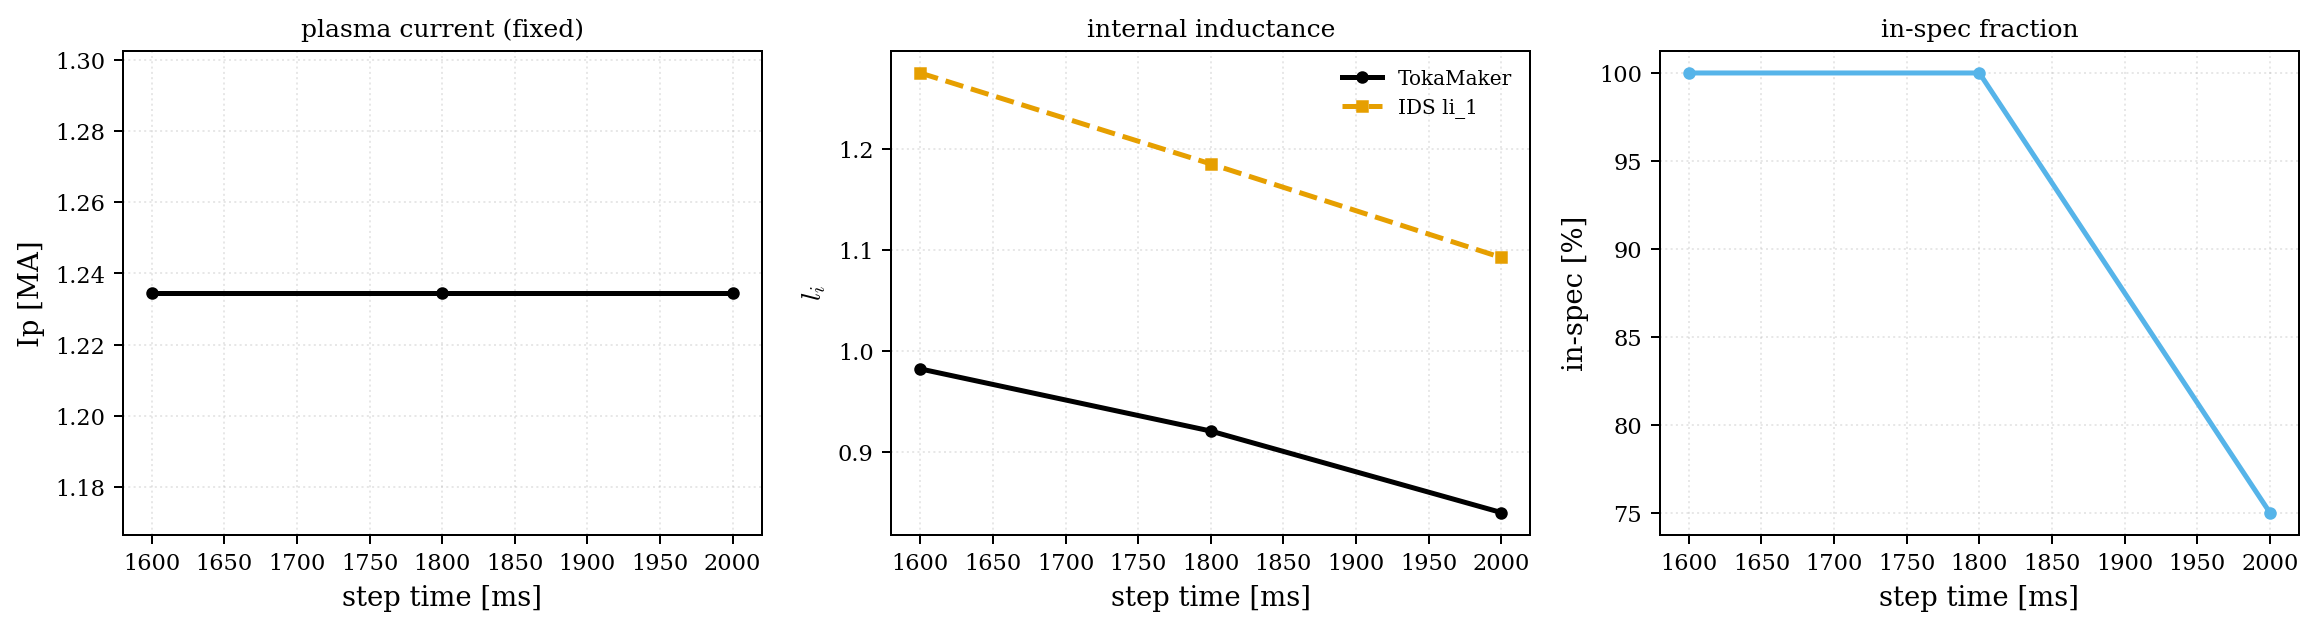

In [21]:
ms = [m['ms'] for m in ts_metrics]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(ms, [m['Ip']/1e6 for m in ts_metrics], 'o-'); ax[0].set_ylabel('Ip [MA]'); ax[0].set_title('plasma current (fixed)')
ax[1].plot(ms, [m['li'] for m in ts_metrics], 'o-', label='TokaMaker')
ax[1].plot(ms, [m['ids_li_1'] for m in ts_metrics], 's--', label='IDS li_1')
ax[1].set_ylabel(r'$l_i$'); ax[1].set_title('internal inductance'); ax[1].legend(fontsize=8)
ax[2].plot(ms, [100*m['n_sel']/max(m['n_all'],1) for m in ts_metrics], 'o-', color='C2')
ax[2].set_ylabel('in-spec [%]'); ax[2].set_title('in-spec fraction')
for a in ax: a.set_xlabel('step time [ms]'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Finally, the **bouquet profile families overlaid across time** — every slice's
baseline (bold), its perturbed draws (thin) and its ±1σ envelope (band), each
colored by its time slice (`plot_bouquet_timeseries`). This shows how the
ensemble *and* its spread evolve through the transition in one figure.


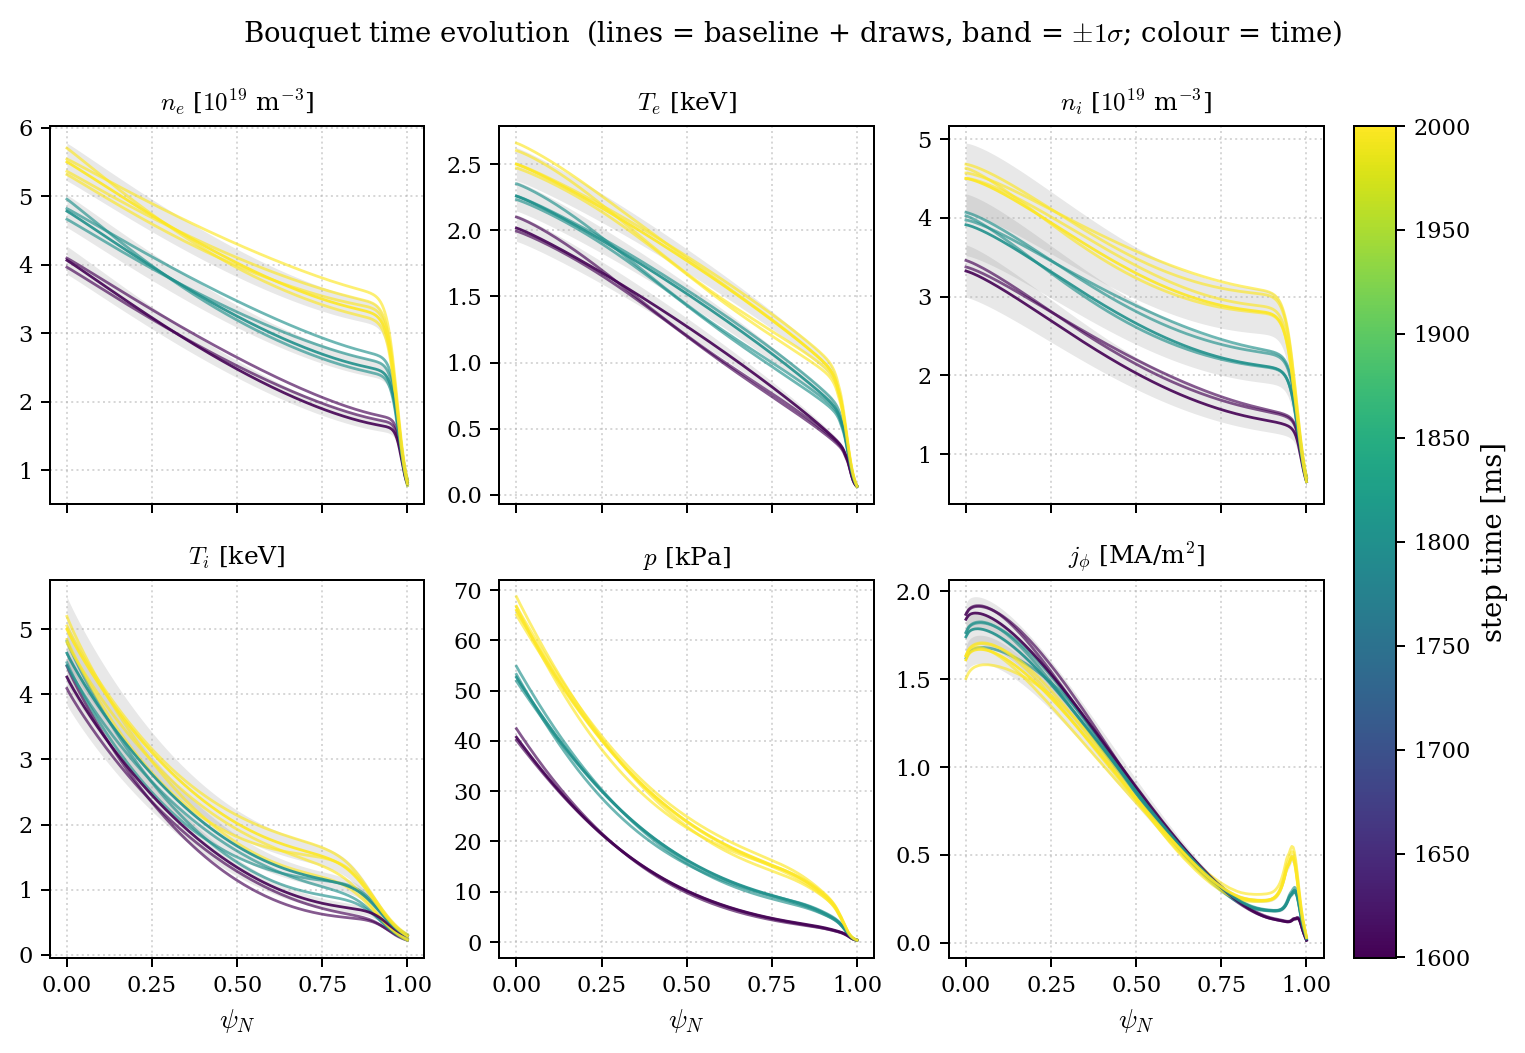

In [22]:
# plot_bouquet_timeseries flags: draws={T|F}  envelopes={T|F}  selection={all|selected|excluded}  cmap='viridis'  time_label  scan_key
bq.plot_bouquet_timeseries(TS, time_label='step time [ms]'); plt.show()


## 8. Perturbed IMAS/OMAS output for downstream codes

Each draw's solved equilibrium is archived as a machine-precision GS eqdsk
(257² ψ(R,Z) + 1D F/FF′/P′/P/q + boundary). `write_imas_draw` reconstructs a
**full IMAS/OMAS IDS** per draw from the `.h5`: the eqdsk maps losslessly to
`equilibrium` (`profiles_1d/2d`, `global_quantities`, `boundary`), and the
perturbed `core_profiles` (kinetics + Z_eff + currents) come from the archive —
ready for transport / MHD-stability codes that consume IMAS.

**Current-split fidelity.** `j_tor` and the equilibrium are always exact. The
*parallel* split IMAS stores (`j_total`/`j_ohmic`/`j_bootstrap` = ⟨**j·B**⟩/B₀)
needs a flux-surface geometry factor, and `fidelity` selects where it comes from:

- `"exact"` — the draw's **own** flux-surface averages, captured live from the
  TokaMaker object at generate time (the `eq_fsa` block; `capture_live_eq=True`
  by default) and converted with `physics.toroidal_to_parallel`.
- `"reconstruct"` — the baseline template ratio `c = j_tor/j_total` (exact only
  when a draw's flux geometry matches the baseline's).
- `"auto"` *(default)* — exact when the `eq_fsa` block is present, else reconstruct.

For a non-IMAS hand-off, `export_bundle` / `ScanView.extract` writes a per-draw
g-file + a self-describing profiles JSON (profiles + units + scalars + coils +
`eq_fsa`) instead.

In [23]:
# write_imas_draw flags:  scan_key  time  fidelity={auto|exact|reconstruct}
# export_imas_drawset flags:  selection={selected|all|excluded}  time  fidelity
# one perturbed IDS for the first in-spec draw (band-rejection leaves index
# gaps, so don't assume draw 0 exists). fidelity='exact' converts the parallel
# split with the draw's OWN captured flux-surface geometry (eq_fsa).
d0  = bq.select_indices(HEADER, scan_key=2000, selection='selected')[0]
ids = bq.write_imas_draw(HEADER, d0, OMAS, 'draw0_perturbed.json',
                         time=TIME, fidelity='exact')
out = json.load(open(ids))
ie  = int(np.argmin(abs(np.asarray(out['equilibrium']['time'], float) - TIME)))
ts  = out['equilibrium']['time_slice'][ie]
print('wrote', ids)
print('  equilibrium.profiles_2d psi grid:',
      np.asarray(ts['profiles_2d'][0]['psi']).shape)
print('  global q_95=%.2f  Ip=%.3f MA  l_i(3)=%.3f' % (
    ts['global_quantities']['q_95'], ts['global_quantities']['ip'] / 1e6,
    ts['global_quantities']['li_3']))

# exact vs reconstruct: how far does the draw's own flux geometry move the
# parallel split from the baseline-ratio fallback? (same draw, j_bootstrap)
def _jbs(path):
    cp = json.load(open(path))['core_profiles']
    k  = int(np.argmin(abs(np.asarray(cp['time'], float) - TIME)))
    return np.asarray(cp['profiles_1d'][k]['j_bootstrap'], float)
rec = bq.write_imas_draw(HEADER, d0, OMAS, 'draw0_reconstruct.json',
                         time=TIME, fidelity='reconstruct')
jb_e, jb_r = _jbs(ids), _jbs(rec)
den = max(np.abs(jb_r).max(), 1e-30)
print('  exact vs reconstruct j_bootstrap:  max|Δ|/max|j| = %.2f%%'
      % (100 * np.abs(jb_e - jb_r).max() / den))

# ...or the whole in-spec family at once (one IDS per selected draw)
paths = bq.export_imas_drawset(HEADER, OMAS, 'imas_out',
                               time=TIME, selection='selected', fidelity='exact')
print(f'\nexport_imas_drawset wrote {len(paths)} selected-draw IDS into imas_out/')

# non-IMAS hand-off: per-draw geqdsk + self-describing profiles JSON bundle
bundle = bq.BouquetArchive(HEADER)['2000'].extract(
    'bundle_out', formats=('geqdsk', 'profiles'), selection='selected')
print(f'ScanView.extract wrote {len(bundle)} draw bundles '
      '(geqdsk + profiles JSON) into bundle_out/')

wrote draw0_perturbed.json
  equilibrium.profiles_2d psi grid: (257, 257)
  global q_95=3.85  Ip=1.235 MA  l_i(3)=0.838


  exact vs reconstruct j_bootstrap:  max|Δ|/max|j| = 4.11%



export_imas_drawset wrote 5 selected-draw IDS into imas_out/
ScanView.extract wrote 5 draw bundles (geqdsk + profiles JSON) into bundle_out/
